# Fraud Detection
## FraudShield AI — Level 1: Core Machine Learning Model

### Objective

To develop a robust machine learning model to identify fraudulent
mobile financial transactions and evaluate its technical and
financial impact.

### Key Goals

- Understand transaction and fraud patterns
- Perform comprehensive exploratory data analysis
- Engineer meaningful transaction and account-level features
- Compare multiple machine learning classifiers
- Evaluate precision, recall, F1-score, ROC-AUC and PR-AUC
- Analyze financial consequences of model errors
- Optimize the decision threshold based on business impact
- Explain predictions using SHAP
- Select and save the final production-oriented model

#### Step 1 - Import Libraries

In [1]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os

os.environ.pop("REQUESTS_CA_BUNDLE", None)
os.environ.pop("CURL_CA_BUNDLE", None)
os.environ.pop("SSL_CERT_FILE", None)

print("Certificate environment variables cleared.")

Certificate environment variables cleared.


In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


#### Step 2 - Load Dataset

In [4]:
DATA_PATH = "Fraud_Analysis_Dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Dataset loaded successfully!
Rows    : 11,142
Columns : 10


#### Step 3 — First inspection

In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


In [7]:
print("Dataset columns:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02}. {column}")

Dataset columns:

01. step
02. type
03. amount
04. nameOrig
05. oldbalanceOrg
06. newbalanceOrig
07. nameDest
08. oldbalanceDest
09. newbalanceDest
10. isFraud


#### Step 4 — Statistical overview

In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,11142.0,NaN,NaN,NaN,8.717645,16.067479,1.0,2.0,6.0,7.0,95.0
type,11142,5,PAYMENT,5510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,11142.0,NaN,NaN,NaN,213191.485084,760065.007673,2.39,4946.6175,16761.26,154336.575,10000000.0
nameOrig,11142,11142,C1305486145,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceOrg,11142.0,NaN,NaN,NaN,924117.256369,2143004.314182,0.0,427.0,28169.5,304085.48,19900000.0
newbalanceOrig,11142.0,NaN,NaN,NaN,824957.648087,2089894.174043,0.0,0.0,4420.605,111412.635,13000000.0
nameDest,11142,7508,C985934102,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceDest,11142.0,NaN,NaN,NaN,888354.084351,2601375.850521,0.0,0.0,0.0,271155.4725,33000000.0
newbalanceDest,11142.0,NaN,NaN,NaN,1103211.480199,2982447.121575,0.0,0.0,0.0,318637.36,34600000.0
isFraud,11142.0,NaN,NaN,NaN,0.102495,0.303312,0.0,0.0,0.0,0.0,1.0


In [9]:
df["isFraud"].value_counts()

isFraud
0    10000
1     1142
Name: count, dtype: int64

In [10]:
# Percentage of transactions
fp = round(df[df["isFraud"]==1].shape[0] * 100 / df.shape[0], 2)
nfp = 100 - fp

print(f"Fraudulent: {fp}%")
print(f"Legitimate: {nfp}%")

Fraudulent: 10.25%
Legitimate: 89.75%


In [11]:
df["nameOrig"].nunique()

11142

In [12]:
df["nameDest"].nunique()

7508

In [13]:
print("Min:", round(df["amount"].min(),2))
print("Max:", round(df["amount"].max(),2))
print("\n")
print("Mean:", round(df["amount"].mean(),2))
print("Median:", round(df["amount"].median(),2))

Min: 2.39
Max: 10000000.0


Mean: 213191.49
Median: 16761.26


#### Observations:
- 10.25% fraudulent trans - Imbalanced
- nameOrg has different originating Customer ID - Cannot be one-hot encode
- nameDest has repeated dest accounts
- type is imp among categorical predictors
- range of amount is enormous & huge difference in mean & median - (Describes right-skewed distribution)

#### Step 5 - Exploratory Data Analysis

In [14]:
fraud_counts = df["isFraud"].value_counts()

print("Transaction Class Distribution:")
print(fraud_counts)

print("\nPercentage Distribution:")
print((fraud_counts / len(df) * 100).round(2))

Transaction Class Distribution:
isFraud
0    10000
1     1142
Name: count, dtype: int64

Percentage Distribution:
isFraud
0    89.75
1    10.25
Name: count, dtype: float64


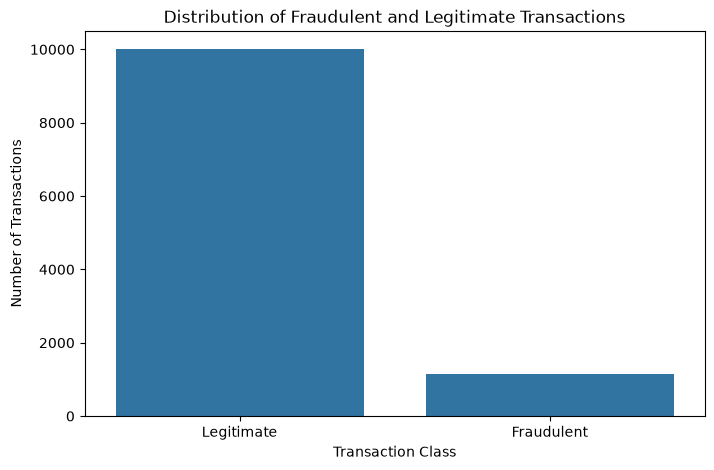

In [15]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="isFraud"
)

plt.title("Distribution of Fraudulent and Legitimate Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraudulent"]
)

plt.show()

##### <span style="color:yellow">Transaction-type Analysis</span>

In [16]:
type_distribution = (
    df["type"]
    .value_counts()
    .reset_index()
)

type_distribution.columns = ["Transaction Type", "Count"]

type_distribution

,Transaction Type,Count
0,PAYMENT,5510
1,CASH_IN,1951
2,CASH_OUT,1871
3,TRANSFER,1464
4,DEBIT,346


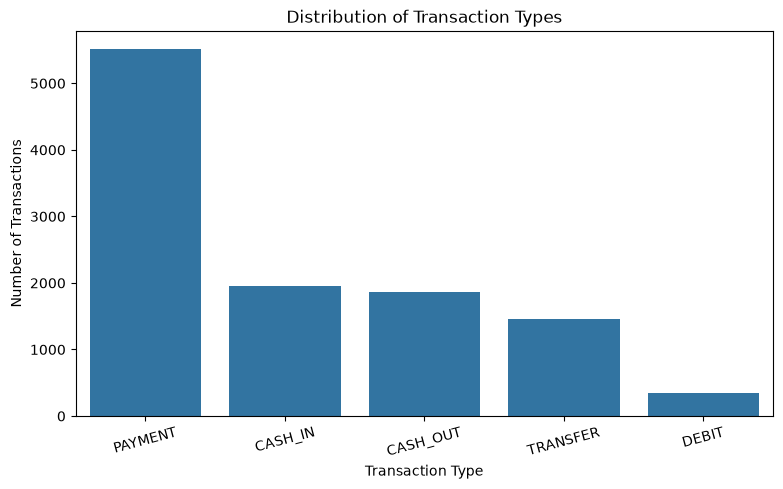

In [17]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="type",
    order=df["type"].value_counts().index
)

plt.title("Distribution of Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=15)

plt.show()

In [18]:
fraud_by_type = (
    df.groupby("type")["isFraud"]
      .agg(["count", "sum", "mean"])
      .sort_values("mean", ascending=False)
)

fraud_by_type.columns = [
    "Total Transactions",
    "Fraudulent Transactions",
    "Fraud Rate"
]

fraud_by_type["Fraud Rate (%)"] = (
    fraud_by_type["Fraud Rate"] * 100
).round(2)

fraud_by_type

,Total Transactions,Fraudulent Transactions,Fraud Rate,Fraud Rate (%)
type,,,,
TRANSFER,1464,564,0.385246,38.52
CASH_OUT,1871,578,0.308926,30.89
CASH_IN,1951,0,0.000000,0.00
DEBIT,346,0,0.000000,0.00
PAYMENT,5510,0,0.000000,0.00


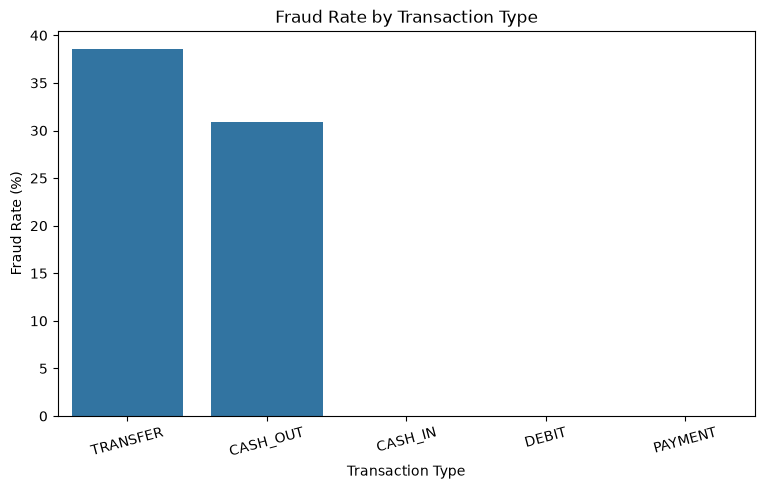

In [19]:
plt.figure(figsize=(9, 5))

fraud_rate_by_type = (
    df.groupby("type")["isFraud"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

sns.barplot(
    x=fraud_rate_by_type.index,
    y=fraud_rate_by_type.values
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=15)

plt.show()

Overall fraud rate: 10.25%

| type | fraud rate |
| --- | --- |
| TRANSFER | 38.52% |
| CASH_OUT | 30.89% |
| OTHER | 0% |

<span style="color:skyblue"><b>EDA Finding 1:</b></span>
- The fraudulent activity in this dataset is entirely concentrated in TRANSFER and CASH_OUT transactions.
- It cannot classify as FRAUD, if type is TRANSFER/CASH_OUT. Because a large no. of these transactions are still legitimate.

| TRANSFER | CASH_OUT |
| --- | --- |
| 1464 total | 1871 total |
| 564 fraud | 578 fraud |
| 900 legitimate | 1293 legitimate |

<span style="color:skyblue"><b>EDA Finding 2:</b></span>
- transaction type is a dominant feature
- discover type_TRANSFER, type_CASH_OUT(strongest features)
- if type in ["CASH_IN", "DEBIT", "PAYMENT"] - low risk
- send TRANSFER, CASH_OUT to ML fraud engine(see whether learn naturally)

##### <span style="color:yellow">Transaction-amount Analysis</span>

In [20]:
# compare trans amount by fraud status

amount_by_fraud = (
    df.groupby("isFraud")["amount"]
      .agg(["count", "mean", "median", "std", "min", "max"])
)

amount_by_fraud.index = ["Legitimate", "Fraudulent"]

amount_by_fraud

,count,mean,median,std,min,max
Legitimate,10000,1.013397e+05,12725.235,2.260189e+05,2.39,3776389.09
Fraudulent,1142,1.192629e+06,353179.450,2.030599e+06,119.00,10000000.00


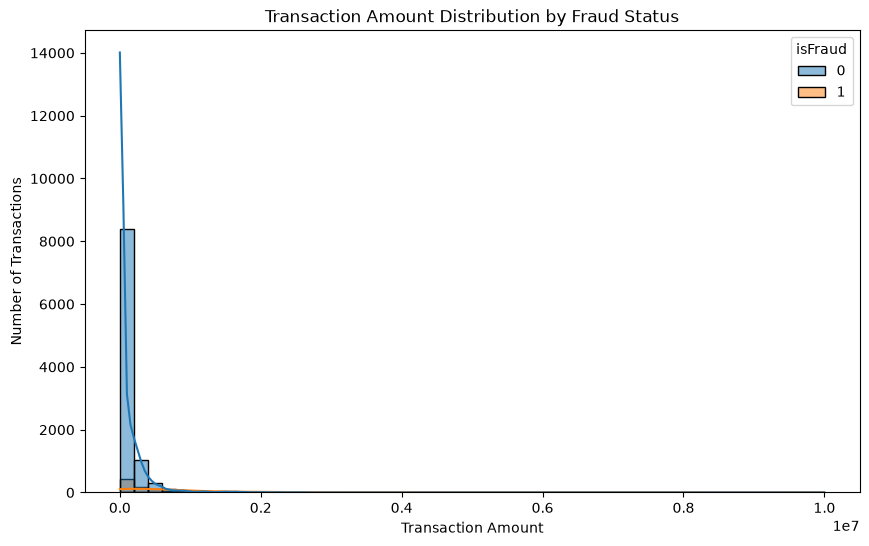

In [21]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="amount",
    hue="isFraud",
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution by Fraud Status")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()

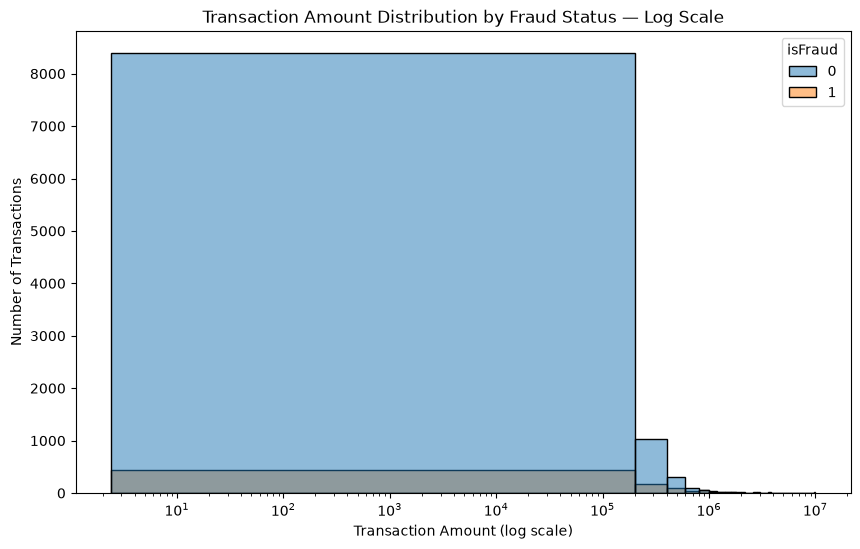

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="amount",
    hue="isFraud",
    bins=50
)

plt.xscale("log")

plt.title("Transaction Amount Distribution by Fraud Status — Log Scale")
plt.xlabel("Transaction Amount (log scale)")
plt.ylabel("Number of Transactions")

plt.show()

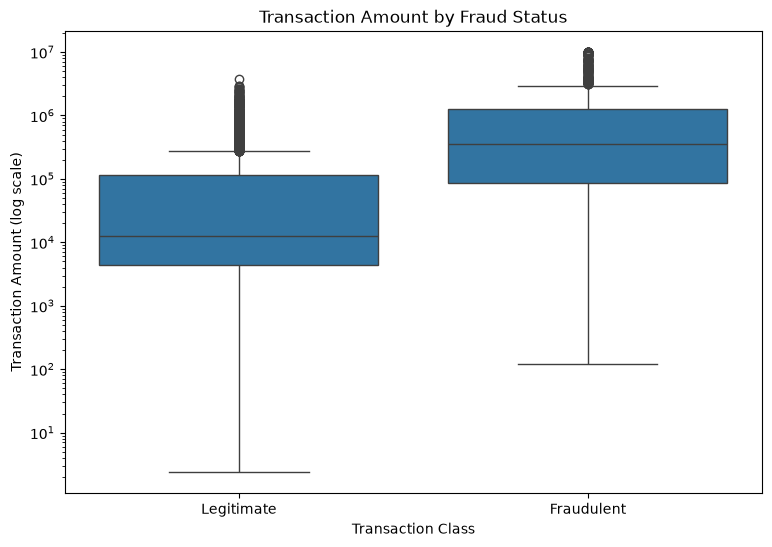

In [23]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="isFraud",
    y="amount"
)

plt.yscale("log")

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount (log scale)")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraudulent"]
)

plt.show()

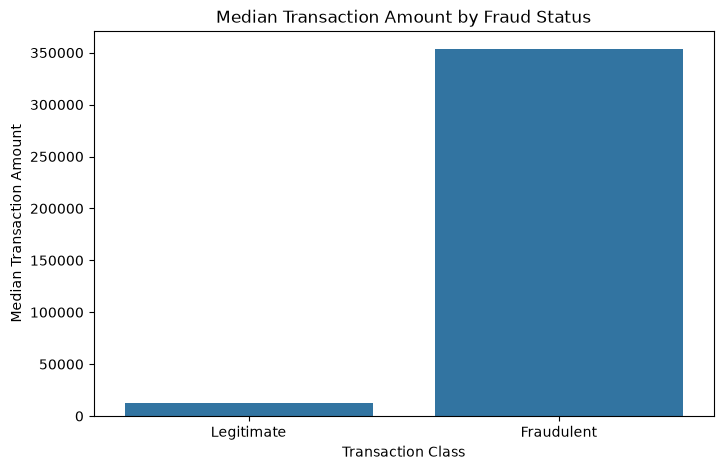

In [24]:
# Median Comparison
median_amounts = (
    df.groupby("isFraud")["amount"]
      .median()
)

median_amounts.index = [
    "Legitimate",
    "Fraudulent"
]

plt.figure(figsize=(8, 5))

sns.barplot(
    x=median_amounts.index,
    y=median_amounts.values
)

plt.title("Median Transaction Amount by Fraud Status")
plt.xlabel("Transaction Class")
plt.ylabel("Median Transaction Amount")

plt.show()

In [25]:
amount_by_fraud.T.round(2)

,Legitimate,Fraudulent
count,10000.00,1142.00
mean,101339.73,1192628.93
median,12725.24,353179.45
std,226018.91,2030598.96
min,2.39,119.00
max,3776389.09,10000000.00


| Metric |	Legitimate |	Fraudulent |
| --- | --- | --- |
|Mean amount	|₹101,339.70	|₹1,192,629.00|
|Median amount	|₹12,725.24	|₹353,179.45|


<span style="color:skyblue"><b>EDA Finding 3:</b></span>
- Fraudulent trans's amounts are larger
- While looking at mean and median of Legitimate & Fraudulent, can say that both distributions are strongly "right-skewed".
- But fraud dist. is extreme (So we cant remove large trans as 'Outliers')

| Metric |	Legitimate |	Fraudulent |
| --- | --- | --- |
| Transactions | 10,000	| 1,142 |
|Std. deviation|	₹226,018.90	|₹2,030,599.00|
|Minimum	|₹2.39	|₹119.00|
|Maximum	|₹3,776,389.09	|₹10,000,000|

##### <span style="color:yellow">Balance Analysis</span>

In [26]:
# Origin Balance stats
origin_balance = (
    df.groupby("isFraud")[
        ["oldbalanceOrg", "newbalanceOrig"]
    ]
    .agg(["mean", "median", "std"])
)

origin_balance.round(2).T

isFraud                         0           1
oldbalanceOrg  mean     890483.19  1218636.22
               median    21324.50   348705.14
               std     2130393.27  2229806.19
newbalanceOrig mean     915291.37    33944.32
               median    10624.75        0.00
               std     2181328.75   501292.99

In [27]:
# Destination Balance stats
destination_balance = (
    df.groupby("isFraud")[
        ["oldbalanceDest", "newbalanceDest"]
    ]
    .agg(["mean", "median", "std"])
)

destination_balance.round(2).T

isFraud                         0           1
oldbalanceDest mean     938086.81   452866.12
               median        0.00        0.00
               std     2683396.63  1662232.09
newbalanceDest mean    1106097.43  1077940.47
               median        0.00    13798.76
               std     3038860.66  2434195.13

In [28]:
eda_df = df.copy()

eda_df["origin_balance_change"] = (
    eda_df["oldbalanceOrg"] - eda_df["newbalanceOrig"]
)

eda_df["destination_balance_change"] = (
    eda_df["newbalanceDest"] - eda_df["oldbalanceDest"]
)

eda_df["origin_balance_error"] = (
    eda_df["oldbalanceOrg"] - eda_df["amount"] - eda_df["newbalanceOrig"]
)

eda_df["destination_balance_error"] = (
    eda_df["oldbalanceDest"] + eda_df["amount"] - eda_df["newbalanceDest"]
)

eda_df[
    [
        "amount",
        "origin_balance_change",
        "destination_balance_change",
        "origin_balance_error",
        "destination_balance_error",
        "isFraud"
    ]
].head()

,amount,origin_balance_change,destination_balance_change,origin_balance_error,destination_balance_error,isFraud
0,181.0,181.0,0.0,0.0,181.0,1
1,181.0,181.0,-21182.0,0.0,21363.0,1
2,2806.0,2806.0,0.0,0.0,2806.0,1
3,2806.0,2806.0,-26202.0,0.0,29008.0,1
4,20128.0,20128.0,0.0,0.0,20128.0,1


In [29]:
# Comparing balance behavior
balance_analysis = (
    eda_df.groupby("isFraud")[
        [
            "amount",
            "origin_balance_change",
            "destination_balance_change",
            "origin_balance_error",
            "destination_balance_error"
        ]
    ]
    .agg(["mean", "median"])
)

balance_analysis.round(2)

amount            origin_balance_change             \
               mean     median                  mean     median   
isFraud                                                           
0         101339.73   12725.24             -24808.18     538.58   
1        1192628.93  353179.45            1184691.90  348705.14   

        destination_balance_change          origin_balance_error           \
                              mean   median                 mean   median   
isFraud                                                                     
0                        168010.62     0.00           -126147.91 -5573.72   
1                        625074.35  3733.04             -7937.03     0.00   

        destination_balance_error           
                             mean   median  
isFraud                                     
0                       -66670.89  6605.92  
1                       567554.59  9439.94

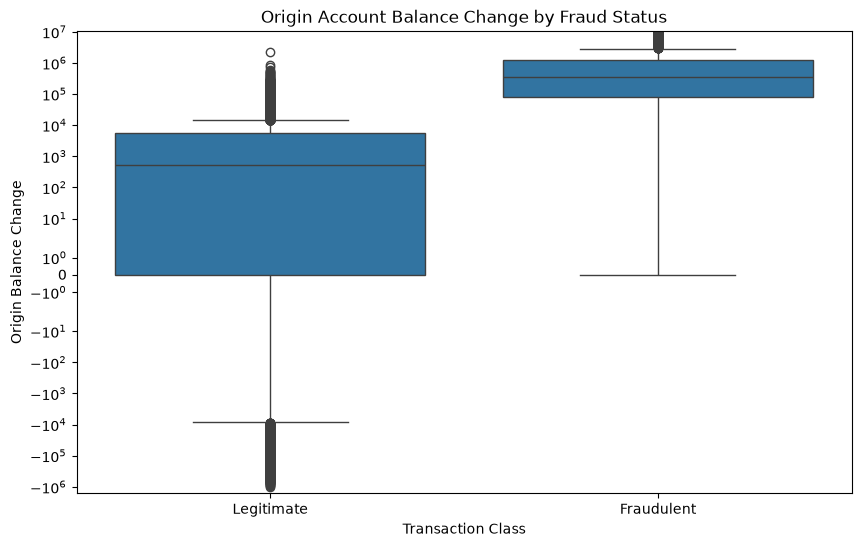

In [30]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=eda_df,
    x="isFraud",
    y="origin_balance_change"
)

plt.yscale("symlog")

plt.title("Origin Account Balance Change by Fraud Status")
plt.xlabel("Transaction Class")
plt.ylabel("Origin Balance Change")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraudulent"]
)

plt.show()

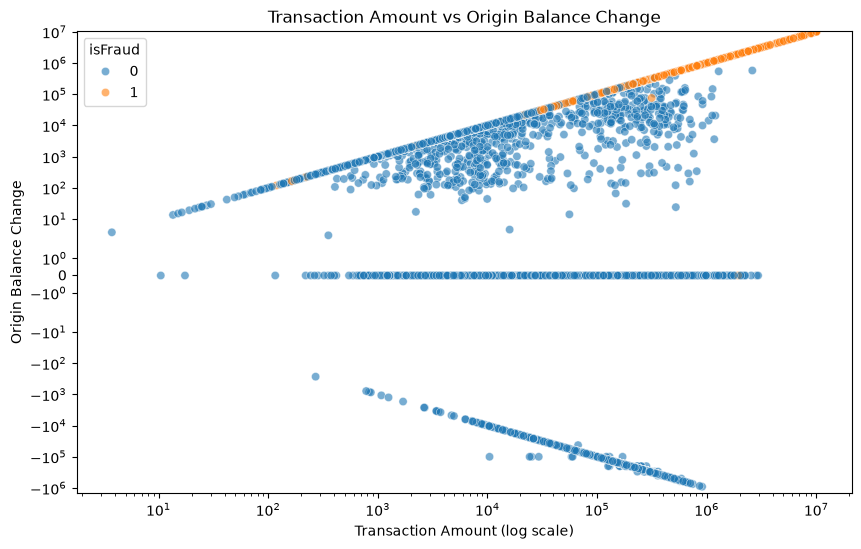

In [31]:
# Fraud vs Legitimate balance consistency
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=eda_df.sample(
        min(5000, len(eda_df)),
        random_state=42
    ),
    x="amount",
    y="origin_balance_change",
    hue="isFraud",
    alpha=0.6
)

plt.xscale("log")
plt.yscale("symlog")

plt.title("Transaction Amount vs Origin Balance Change")
plt.xlabel("Transaction Amount (log scale)")
plt.ylabel("Origin Balance Change")

plt.show()

<span style="color:skyblue"><b>EDA Finding 4:</b></span>
- Origin balance change is very strong signal(look at means and medians) - strongly suggest that fraudulent trans are associated with large movements out of the originating account. (fraudulent agents attempt to take control of accounts, transfer funds, and cash them out)

|---|Median OBC|Mean OBC|
|---|---|---|
|Legitimate|538.58|24,808|
|Fraudulent|348,705.14|1,184,692|

- DBC should not interpret every zero as 'nothing' one 

|---|Median DBC|Mean DBC|
|---|---|---|
|Legitimate|0|168010.62|
|Fraudulent|3,733.04|625074.35|

- OBE, should not immediately call as a fraud indicator(oldb-amount-newb) 

|---|Median OBE|Mean OBE|
|---|---|---|
|Legitimate|-5573.72|-126147.91|
|Fraudulent|0|-7937.03|

- DBE, difference is not merely upto origin balance movement (small amounts compared)

|---|Median DBE|Mean DBE|
|---|---|---|
|Legitimate|6,605.92|-66,670.89|
|Fraudulent|9,439.94|5,67,554.59|

<small><span style="color:lightgreen">Strong signal</span> - origin_balance_change</small>
<br>
<small><span style="color:yellow">Potential signal</span> - destination_balance_change</small>
<br>
<small><span style="color:pink">Investigate signal</span> - origin_balance_error - destination_balance_error</small>

<span style="color:yellow">Notice something:</span>

|---|Amount|Origin Balance Change|
|---|---|---|
|Fraud Median|<mark style="background-color:lightgreen;">₹353,179.45</mark>|<mark style="background-color:lightgreen;">₹348,705.14</mark>|

<small>They're extremely close.
<br>
That suggests that for fraudulent transactions, the transaction amount and the origin-account balance movement are strongly related.</small>

In [32]:
# Correlation
correlation_features = [
    "amount",
    "origin_balance_change",
    "destination_balance_change",
    "origin_balance_error",
    "destination_balance_error"
]

eda_df[correlation_features].corr()

,amount,origin_balance_change,destination_balance_change,origin_balance_error,destination_balance_error
amount,1.000000,0.943694,0.387728,-0.194992,0.302196
origin_balance_change,0.943694,1.000000,0.320916,0.140457,0.331697
destination_balance_change,0.387728,0.320916,1.000000,-0.208962,-0.761507
origin_balance_error,-0.194992,0.140457,-0.208962,1.000000,0.078985
destination_balance_error,0.302196,0.331697,-0.761507,0.078985,1.000000


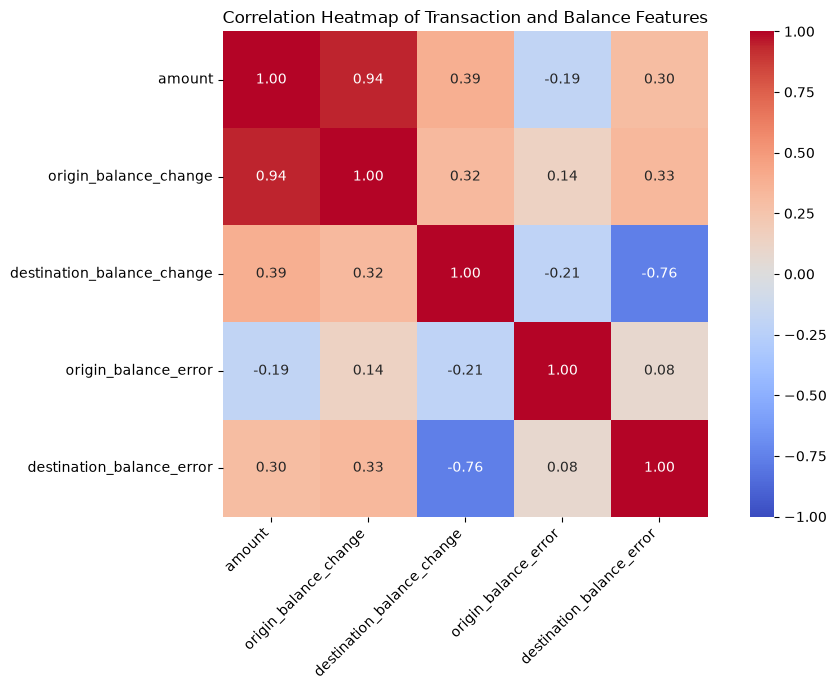

In [33]:
plt.figure(figsize=(10, 7))

correlation_matrix = eda_df[correlation_features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    fmt=".2f",
    square=True
)

plt.title("Correlation Heatmap of Transaction and Balance Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [34]:
fraud_corr = (
    eda_df[eda_df["isFraud"] == 1][correlation_features].corr()
)

fraud_corr

,amount,origin_balance_change,destination_balance_change,origin_balance_error,destination_balance_error
amount,1.000000,0.999116,0.636931,0.010908,0.637826
origin_balance_change,0.999116,1.000000,0.634350,0.052923,0.639280
destination_balance_change,0.636931,0.634350,1.000000,-0.041083,-0.187496
origin_balance_error,0.010908,0.052923,-0.041083,1.000000,0.054942
destination_balance_error,0.637826,0.639280,-0.187496,0.054942,1.000000


In [35]:
legitimate_corr = (
    eda_df[eda_df["isFraud"] == 0][correlation_features].corr()
)

legitimate_corr

,amount,origin_balance_change,destination_balance_change,origin_balance_error,destination_balance_error
amount,1.000000,-0.190616,0.344330,-0.928730,-0.134052
origin_balance_change,-0.190616,1.000000,0.095923,0.540990,-0.144975
destination_balance_change,0.344330,0.095923,1.000000,-0.258772,-0.976533
origin_balance_error,-0.928730,0.540990,-0.258772,1.000000,0.060093
destination_balance_error,-0.134052,-0.144975,-0.976533,0.060093,1.000000


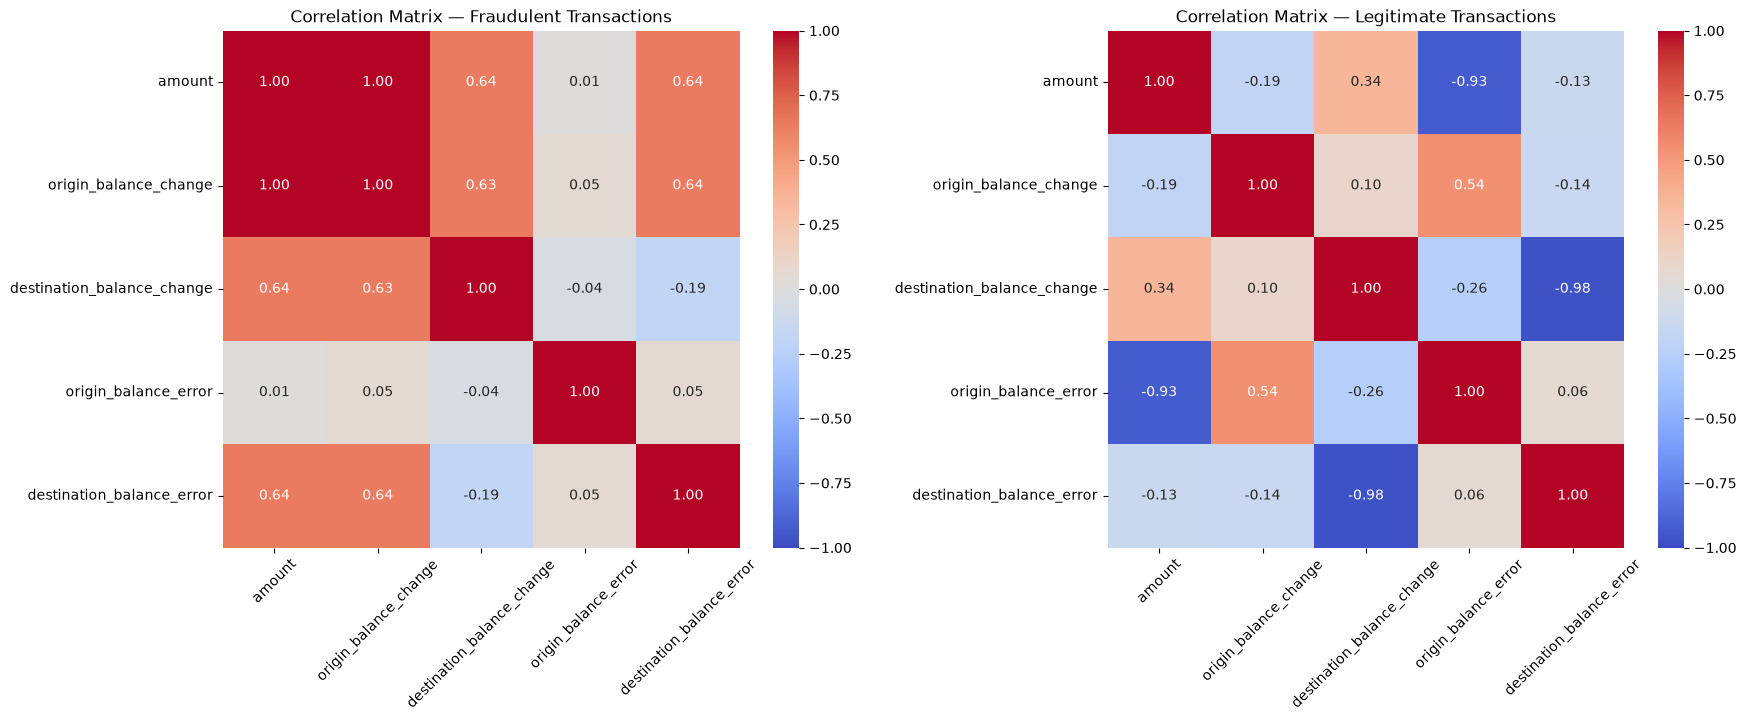

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    fraud_corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    fmt=".2f",
    square=True,
    ax=axes[0]
)
axes[0].set_title("Correlation Matrix — Fraudulent Transactions")
axes[0].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis="y", rotation=0)

sns.heatmap(
    legitimate_corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    fmt=".2f",
    square=True,
    ax=axes[1]
)
axes[1].set_title("Correlation Matrix — Legitimate Transactions")
axes[1].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

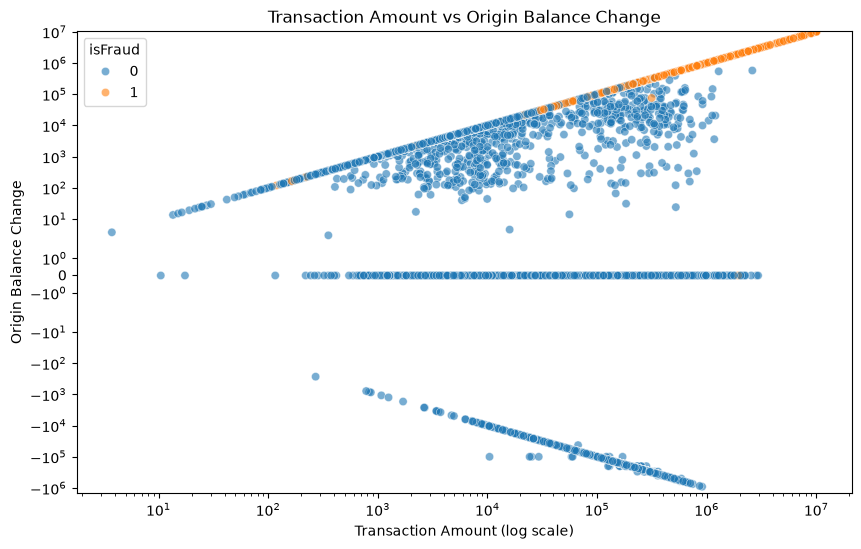

In [37]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=eda_df.sample(
        min(5000, len(eda_df)),
        random_state=42
    ),
    x="amount",
    y="origin_balance_change",
    hue="isFraud",
    alpha=0.6
)

plt.xscale("log")
plt.yscale("symlog")

plt.title(
    "Transaction Amount vs Origin Balance Change"
)
plt.xlabel("Transaction Amount (log scale)")
plt.ylabel("Origin Balance Change")

plt.show()

In [38]:
# we have amount, oldbalanceOrg, newbalanceOrig
# calculate amount_to_origin_balance_ratio
# amount / oldbalanceOrg = amount_to_origin_balance_ratio

eda_df["amount_to_origin_balance_ratio"] = np.where(
    eda_df["oldbalanceOrg"] > 0,
    eda_df["amount"] / eda_df["oldbalanceOrg"],
    0
)

eda_df.groupby("isFraud")[
    "amount_to_origin_balance_ratio"
].agg([
    "mean",
    "median",
    "std",
    "min",
    "max"
])

,mean,median,std,min,max
isFraud,,,,,
0,14.048227,0.058194,264.395076,0.0,21761.033750
1,1.024237,1.000000,1.026141,0.0,29.526623


<span style="color:skyblue"><b>EDA Finding 5:</b></span>
- Fraudulent <mark style="background-color:lightgrey">(Amount <-> origin_balance_change) = 0.9991 </mark>(perfect +ve linear relationship)
- So for fraud cases, when the transaction amount increases, the originating account's balance movement almost perfectly increases with it.
<br>
- Legitimate <mark style="background-color:lightgrey">(Amount ↔ origin balance change) = -0.1906 </mark>(-ve)
<br>
<br>
- <small><i>origin_balance_change = oldbalanceOrg-newbalanceOrig</i>
<br>
If fraudulent transfers in this simulated dataset almost always reduce the origin balance by exactly the transaction amount, then: 
<br>
<b>origin_balance_change ≈ amount</b></small>


##### <span style="color:yellow">Exact Balance relationship</span>

In [39]:
# Exact balance relationship

balance_check = eda_df[
    [
        "type",
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "origin_balance_change",
        "origin_balance_error",
        "isFraud"
    ]
].copy()

balance_check["abs_origin_balance_error"] = (
    balance_check["origin_balance_error"].abs()
)

balance_check.sort_values(
    "abs_origin_balance_error",
    ascending=False
).head(40)

,type,amount,oldbalanceOrg,newbalanceOrig,origin_balance_change,origin_balance_error,isFraud,abs_origin_balance_error
2284,TRANSFER,3776389.09,0.00,0.00,0.00,-3776389.09,0,3776389.09
11133,TRANSFER,2943845.35,0.00,0.00,0.00,-2943845.35,0,2943845.35
10709,TRANSFER,2940764.72,0.00,0.00,0.00,-2940764.72,0,2940764.72
11134,TRANSFER,2861134.92,0.00,0.00,0.00,-2861134.92,0,2861134.92
5271,TRANSFER,2837270.65,0.00,0.00,0.00,-2837270.65,0,2837270.65
8775,TRANSFER,2576294.80,0.00,0.00,0.00,-2576294.80,0,2576294.80
1513,TRANSFER,2545478.01,0.00,0.00,0.00,-2545478.01,0,2545478.01
10273,TRANSFER,2511647.23,0.00,0.00,0.00,-2511647.23,0,2511647.23
4678,TRANSFER,2474181.78,0.00,0.00,0.00,-2474181.78,0,2474181.78
3713,TRANSFER,2441078.30,0.00,0.00,0.00,-2441078.30,0,2441078.30


In [40]:
eda_df["origin_change_amount_difference"] = (
    eda_df["origin_balance_change"] - eda_df["amount"]
)

eda_df["abs_origin_change_amount_difference"] = (
    eda_df["origin_change_amount_difference"].abs()
)

eda_df["origin_change_amount_difference"].head(20)

0          0.00
1          0.00
2          0.00
3          0.00
4          0.00
5          0.00
6    -416001.33
7          0.00
8          0.00
9          0.00
10         0.00
11         0.00
12         0.00
13   -128343.56
14         0.00
15         0.00
16         0.00
17         0.00
18         0.00
19         0.00
Name: origin_change_amount_difference, dtype: float64

In [41]:
eda_df.groupby("isFraud")[
    "abs_origin_change_amount_difference"
].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
])

,count,mean,median,std,min,max
isFraud,,,,,,
0,10000,126147.908380,5573.715,263813.427179,0.0,3776389.09
1,1142,8058.776138,0.000,85448.264116,0.0,1933920.80


<small>The fraudulent median is near zero, we'll have quantitative evidence that, for Fraudulent trans the originating balance reduction closely matches the transaction amount.</small>

In [42]:
#Exact matching percentage

for fraud_status, group in eda_df.groupby("isFraud"):
    
    close_match = (
        group["abs_origin_change_amount_difference"] < 1
    ).mean() * 100
    
    label = "Fraudulent" if fraud_status == 1 else "Legitimate"
    
    print(
        f"{label}: "
        f"{close_match:.2f}% of transactions "
        f"have balance change within ₹1 of transaction amount."
    )

Legitimate: 40.18% of transactions have balance change within ₹1 of transaction amount.
Fraudulent: 97.29% of transactions have balance change within ₹1 of transaction amount.


In [43]:
eda_df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,origin_balance_change,destination_balance_change,origin_balance_error,destination_balance_error,amount_to_origin_balance_ratio,origin_change_amount_difference,abs_origin_change_amount_difference
0,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.0,0.00,1,181.00,0.00,0.00,181.00,1.0,0.00,0.00
1,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.0,0.00,1,181.00,-21182.00,0.00,21363.00,1.0,0.00,0.00
2,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.0,0.00,1,2806.00,0.00,0.00,2806.00,1.0,0.00,0.00
3,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.0,0.00,1,2806.00,-26202.00,0.00,29008.00,1.0,0.00,0.00
4,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.0,0.00,1,20128.00,0.00,0.00,20128.00,1.0,0.00,0.00
5,1,CASH_OUT,20128.00,C1118430673,20128.00,0.0,C339924917,6268.0,12145.85,1,20128.00,5877.85,0.00,14250.15,1.0,0.00,0.00
6,1,CASH_OUT,416001.33,C749981943,0.00,0.0,C667346055,102.0,9291619.62,1,0.00,9291517.62,-416001.33,-8875516.29,0.0,-416001.33,416001.33
7,1,TRANSFER,1277212.77,C1334405552,1277212.77,0.0,C431687661,0.0,0.00,1,1277212.77,0.00,0.00,1277212.77,1.0,0.00,0.00
8,1,CASH_OUT,1277212.77,C467632528,1277212.77,0.0,C716083600,0.0,2444985.19,1,1277212.77,2444985.19,0.00,-1167772.42,1.0,0.00,0.00
9,1,TRANSFER,35063.63,C1364127192,35063.63,0.0,C1136419747,0.0,0.00,1,35063.63,0.00,0.00,35063.63,1.0,0.00,0.00


In [44]:
balance_check.head(10)

,type,amount,oldbalanceOrg,newbalanceOrig,origin_balance_change,origin_balance_error,isFraud,abs_origin_balance_error
0,TRANSFER,181.00,181.00,0.0,181.00,0.00,1,0.00
1,CASH_OUT,181.00,181.00,0.0,181.00,0.00,1,0.00
2,TRANSFER,2806.00,2806.00,0.0,2806.00,0.00,1,0.00
3,CASH_OUT,2806.00,2806.00,0.0,2806.00,0.00,1,0.00
4,TRANSFER,20128.00,20128.00,0.0,20128.00,0.00,1,0.00
5,CASH_OUT,20128.00,20128.00,0.0,20128.00,0.00,1,0.00
6,CASH_OUT,416001.33,0.00,0.0,0.00,-416001.33,1,416001.33
7,TRANSFER,1277212.77,1277212.77,0.0,1277212.77,0.00,1,0.00
8,CASH_OUT,1277212.77,1277212.77,0.0,1277212.77,0.00,1,0.00
9,TRANSFER,35063.63,35063.63,0.0,35063.63,0.00,1,0.00


In [45]:
# Transaction type balance analysis

type_balance_analysis = (
    eda_df.groupby(["type", "isFraud"])[
        [
            "amount",
            "origin_balance_change",
            "origin_balance_error"
        ]
    ]
    .agg(["mean", "median"])
)

type_balance_analysis.round(2)

amount            origin_balance_change             \
                        mean     median                  mean     median   
type     isFraud                                                           
CASH_IN  0         167994.82  137054.90            -165821.91 -133997.01   
CASH_OUT 0         164315.86  128278.74              15714.38       0.00   
         1        1177134.71  350747.66            1169544.97  338635.14   
DEBIT    0           3590.69    3026.65               3156.80    2598.40   
PAYMENT  0           7891.18    5772.74               4743.96    2737.55   
TRANSFER 0         476062.43  286268.04              30985.07     131.00   
         1        1208507.77  359262.44            1200214.82  353179.45   

                 origin_balance_error             
                                 mean     median  
type     isFraud                                  
CASH_IN  0                 -333816.73 -270689.79  
CASH_OUT 0                 -148601.48 -114057.61  
         1                   -7589.74       0.00  
DEBIT    0                    -433.89       0.00  
PAYMENT  0                   -3147.22       0.00  
TRANSFER 0                 -445077.36 -251673.50  
         1                   -8292.95       0.00

<span style="color:skyblue"><b>EDA Finding 6:</b></span>
- <b>97.29%</b> of fraudulent transactions have an originating-account balance reduction within ₹1 of the transaction amount
- Fraudulent transactions almost completely empty the origin account
<br>

Median of Legitimate:
|---|amount|origin_balance_change|
|---|---|---|
|CASH_OUT|1,28,278.74|0.00|
|TRANSFER|2,86,268.04|131|

Median of Fraudulent:
|---|amount|origin_balance_change|
|---|---|---|
|CASH_OUT|3,50,747.66|3,38,635.14|
|TRANSFER|3,59,262|3,53,179.45|

- Complete origin-balance depletion pattern seen in fraudulent transfers, legitimate transfers frequently do not exhibit the same.

```mermaid
flowchart TD
    A[FRAUD PATTERN] --- B[TRANSFER]
    A --- C[CASH_OUT]
    B --> D[Large Transaction]
    C --> D
    D --> E[Origin account loses approx. amount]
    E --> F[Account Depletion]
```

##### <span style="color:yellow">Balance Match Analysis</span>

In [46]:
# Balnce match analysis

eda_df["balance_amount_match"] = (
    eda_df["abs_origin_change_amount_difference"] <= 1
).astype(int)

eda_df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,origin_balance_change,destination_balance_change,origin_balance_error,destination_balance_error,amount_to_origin_balance_ratio,origin_change_amount_difference,abs_origin_change_amount_difference,balance_amount_match
0,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.0,0.00,1,181.00,0.00,0.00,181.00,1.0,0.00,0.00,1
1,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.0,0.00,1,181.00,-21182.00,0.00,21363.00,1.0,0.00,0.00,1
2,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.0,0.00,1,2806.00,0.00,0.00,2806.00,1.0,0.00,0.00,1
3,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.0,0.00,1,2806.00,-26202.00,0.00,29008.00,1.0,0.00,0.00,1
4,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.0,0.00,1,20128.00,0.00,0.00,20128.00,1.0,0.00,0.00,1
5,1,CASH_OUT,20128.00,C1118430673,20128.00,0.0,C339924917,6268.0,12145.85,1,20128.00,5877.85,0.00,14250.15,1.0,0.00,0.00,1
6,1,CASH_OUT,416001.33,C749981943,0.00,0.0,C667346055,102.0,9291619.62,1,0.00,9291517.62,-416001.33,-8875516.29,0.0,-416001.33,416001.33,0
7,1,TRANSFER,1277212.77,C1334405552,1277212.77,0.0,C431687661,0.0,0.00,1,1277212.77,0.00,0.00,1277212.77,1.0,0.00,0.00,1
8,1,CASH_OUT,1277212.77,C467632528,1277212.77,0.0,C716083600,0.0,2444985.19,1,1277212.77,2444985.19,0.00,-1167772.42,1.0,0.00,0.00,1
9,1,TRANSFER,35063.63,C1364127192,35063.63,0.0,C1136419747,0.0,0.00,1,35063.63,0.00,0.00,35063.63,1.0,0.00,0.00,1


In [47]:
balance_match_analysis = (
    eda_df.groupby("balance_amount_match")["isFraud"]
    .agg(["count", "sum", "mean"])
)

balance_match_analysis

,count,sum,mean
balance_amount_match,,,
0,6013,31,0.005155
1,5129,1111,0.216611


In [48]:
balance_match_analysis.columns = [
    "Total Transactions",
    "Fraudulent Transactions",
    "Fraud Rate"
]

balance_match_analysis["Fraud Rate (%)"] = (
    balance_match_analysis["Fraud Rate"] * 100
).round(2)

balance_match_analysis

,Total Transactions,Fraudulent Transactions,Fraud Rate,Fraud Rate (%)
balance_amount_match,,,,
0,6013,31,0.005155,0.52
1,5129,1111,0.216611,21.66


In [49]:
pd.crosstab(
    eda_df["balance_amount_match"],
    eda_df["isFraud"],
    margins=True
)

isFraud,0,1,All
balance_amount_match,,,
0,5982,31,6013
1,4018,1111,5129
All,10000,1142,11142


In [50]:
# Analyzing by type

balance_match_by_type = (
    eda_df.groupby(["type", "balance_amount_match"])["isFraud"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

balance_match_by_type.columns = [
    "Transaction Type",
    "Balance Match",
    "Total Transactions",
    "Fraudulent Transactions",
    "Fraud Rate"
]

balance_match_by_type["Fraud Rate (%)"] = (
    balance_match_by_type["Fraud Rate"] * 100
).round(2)

balance_match_by_type

,Transaction Type,Balance Match,Total Transactions,Fraudulent Transactions,Fraud Rate,Fraud Rate (%)
0,CASH_IN,0,1951,0,0.000000,0.00
1,CASH_OUT,0,1193,19,0.015926,1.59
2,CASH_OUT,1,678,559,0.824484,82.45
3,DEBIT,0,52,0,0.000000,0.00
4,DEBIT,1,294,0,0.000000,0.00
5,PAYMENT,0,1984,0,0.000000,0.00
6,PAYMENT,1,3526,0,0.000000,0.00
7,TRANSFER,0,833,12,0.014406,1.44
8,TRANSFER,1,631,552,0.874802,87.48


<small>Overall fraud rate: <b>10.25%</b><br>
So:<br>
    No Match -> <mark style="background-color:grey">0.52% fraud</mark><br>
    Match -> <mark style="background-color:lightblue">21.66% fraud</mark>(very large seperation)</small>

|---|Legitimate|Fraud|
|---|---|---|
|Balance Match 0|5982|31|
|Balance Match 1|4018|1111|

Total fraud trans: <b>1,142</b><br>
The match condition captures: <b>1,111/1,142 = 97.29%</b> of all fraud.

<span style="color:skyblue"><b>EDA Finding 7:</b></span>
- Balance-amount matching is highly associated with fraud
- We would catch almost all fraud, but we'd flag lot of legitimate trans too

<small style="color:lightgreen">Precision = TP/TP+FP<br>
Precision = (1111/4018+1111)*100 = <b>21.66%</b></small>

<span style="color:violet">Recall -> 97.29%<br>
Precision -> 21.66%</span>

##### <span style="color:yellow">Time Analysis</span>

In [51]:
# Time analysis using "step"
# 1 step = 1 hour

time_analysis = (
    df.groupby("step")
      .agg(
          total_transactions=("isFraud", "count"),
          fraudulent_transactions=("isFraud", "sum"),
          fraud_rate=("isFraud", "mean")
      )
)

time_analysis["fraud_rate_pct"] = (
    time_analysis["fraud_rate"] * 100
).round(2)

time_analysis.head(20)

,total_transactions,fraudulent_transactions,fraud_rate,fraud_rate_pct
step,,,,
1,2708,16,0.005908,0.59
2,1014,8,0.007890,0.79
3,552,4,0.007246,0.72
4,565,10,0.017699,1.77
5,665,6,0.009023,0.90
6,1660,22,0.013253,1.33
7,2914,12,0.004118,0.41
8,12,12,1.000000,100.00
9,19,19,1.000000,100.00


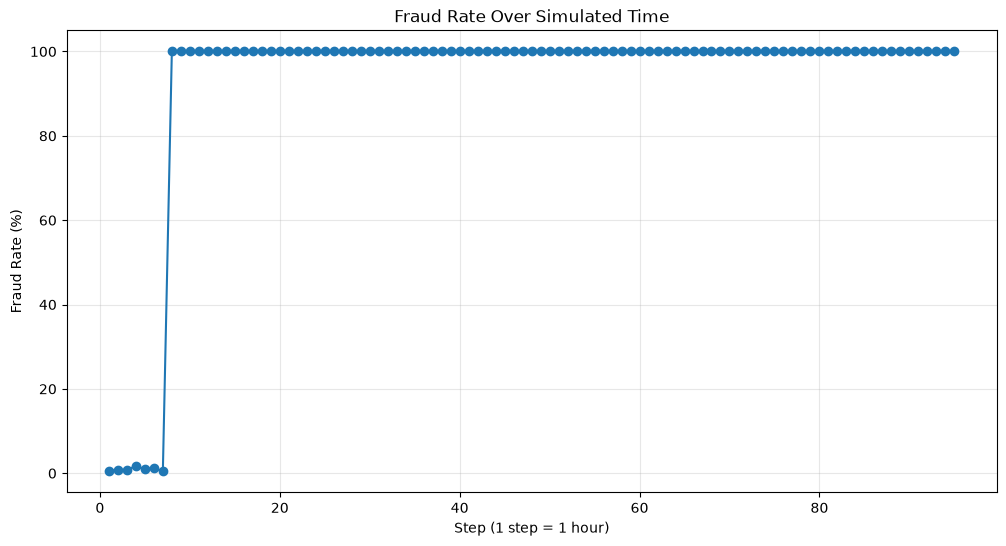

In [52]:
plt.figure(figsize=(12, 6))

plt.plot(
    time_analysis.index,
    time_analysis["fraud_rate_pct"],
    marker="o"
)

plt.title("Fraud Rate Over Simulated Time")
plt.xlabel("Step (1 step = 1 hour)")
plt.ylabel("Fraud Rate (%)")
plt.grid(alpha=0.3)

plt.show()

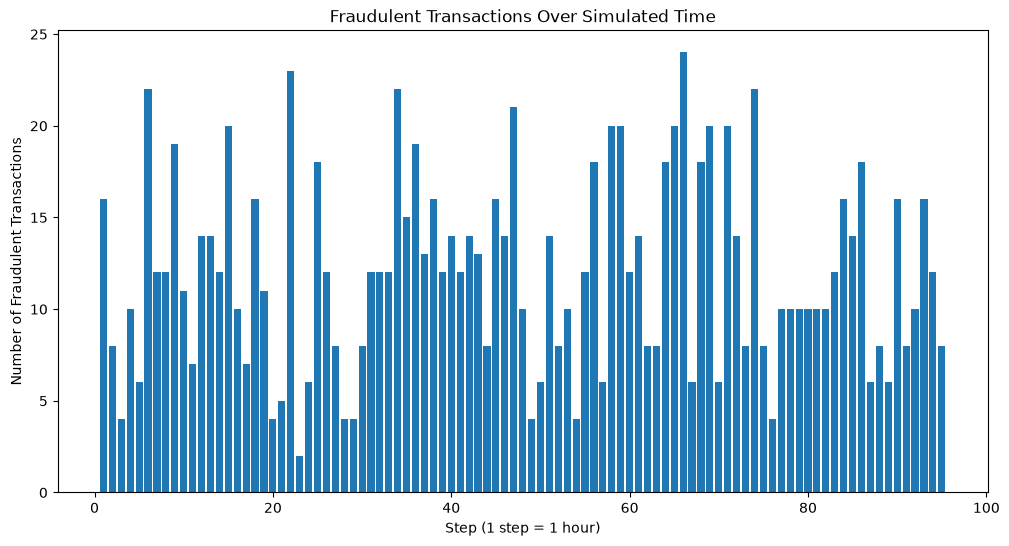

In [53]:
plt.figure(figsize=(12, 6))

plt.bar(
    time_analysis.index,
    time_analysis["fraudulent_transactions"]
)

plt.title("Fraudulent Transactions Over Simulated Time")
plt.xlabel("Step (1 step = 1 hour)")
plt.ylabel("Number of Fraudulent Transactions")

plt.show()

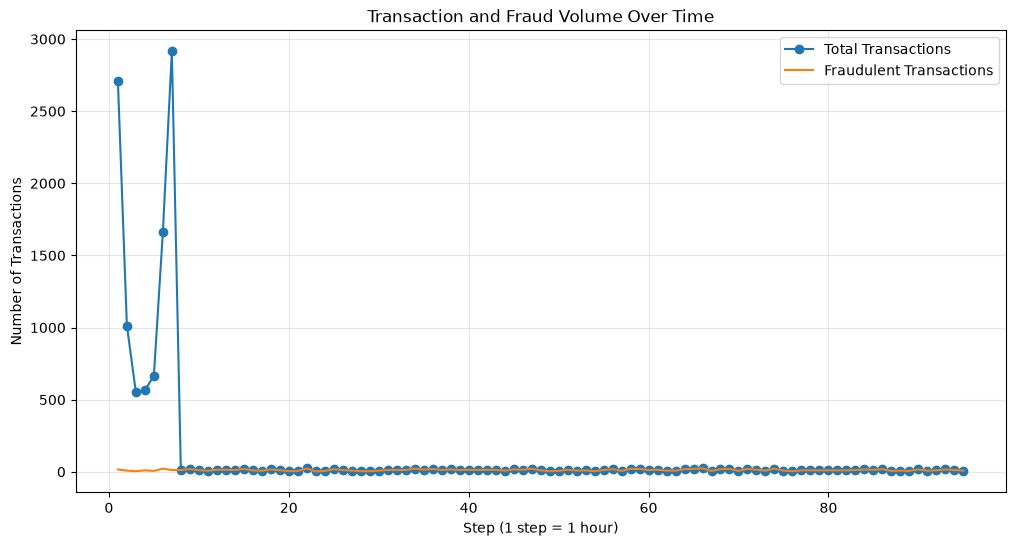

In [54]:
# 

plt.figure(figsize=(12, 6))

plt.plot(
    time_analysis.index,
    time_analysis["total_transactions"],
    label="Total Transactions",
    marker="o"
)

plt.plot(
    time_analysis.index,
    time_analysis["fraudulent_transactions"],
    label="Fraudulent Transactions"
)

plt.title("Transaction and Fraud Volume Over Time")
plt.xlabel("Step (1 step = 1 hour)")
plt.ylabel("Number of Transactions")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<small>Transaction volume varies dramatically across simulated time, with extremely high transaction activity concentrated in the earliest steps and substantially lower activity afterward.</small>

<small>Step 1 → huge volume<br>
Step 6/7 → huge volume<br>
Step 8+ → tiny volume<br>
<br>
If <mark style="background-color:lightblue">step >= 8 → fraud</mark> (not confirmed, this feature not only makes model robust, yet to see)
</small>

In [55]:
time_analysis

,total_transactions,fraudulent_transactions,fraud_rate,fraud_rate_pct
step,,,,
1,2708,16,0.005908,0.59
2,1014,8,0.007890,0.79
3,552,4,0.007246,0.72
4,565,10,0.017699,1.77
5,665,6,0.009023,0.90
...,...,...,...,...
91,8,8,1.000000,100.00
92,10,10,1.000000,100.00
93,16,16,1.000000,100.00


In [56]:
#Finding first step with 100% fraud

first_100_fraud_step = (
    time_analysis[
        time_analysis["fraud_rate"] == 1
    ].index.min()
)

print(
    "First step with 100% fraud:",
    first_100_fraud_step
)

First step with 100% fraud: 8


In [57]:
after_first_100 = time_analysis.loc[
    first_100_fraud_step:
]

print(
    "Number of steps after first 100% fraud step:", len(after_first_100)
)

print(
    "Steps with fraud rate below 100%:",
    (after_first_100["fraud_rate"] < 1).sum()
)

Number of steps after first 100% fraud step: 88
Steps with fraud rate below 100%: 0


In [58]:
early_period = df[df["step"] < 8]

late_period = df[df["step"] >= 8]

print("EARLY PERIOD (step < 8)")
print("Transactions:", len(early_period))
print("Fraud:", early_period["isFraud"].sum())
print(
    "Fraud rate:",
    early_period["isFraud"].mean() * 100
)

print("\nLATE PERIOD (step >= 8)")
print("Transactions:", len(late_period))
print("Fraud:", late_period["isFraud"].sum())
print(
    "Fraud rate:",
    late_period["isFraud"].mean() * 100
)

EARLY PERIOD (step < 8)
Transactions: 10078
Fraud: 78
Fraud rate: 0.7739630879142687

LATE PERIOD (step >= 8)
Transactions: 1064
Fraud: 1064
Fraud rate: 100.0


In [59]:
step_period_analysis = pd.crosstab(
    df["step"] < 8,
    df["isFraud"],
    margins=True
)

step_period_analysis.index = [
    "Step >= 8",
    "Step < 8",
    "All"
]

step_period_analysis

isFraud,0,1,All
Step >= 8,0,1064,1064
Step < 8,10000,78,10078
All,10000,1142,11142


In [60]:
step_period = np.where(
    df["step"] < 8,
    "Early (step < 8)",
    "Late (step >= 8)"
)

pd.crosstab(
    step_period,
    df["isFraud"],
    margins=True
)

isFraud,0,1,All
row_0,,,
Early (step < 8),10000,78,10078
Late (step >= 8),0,1064,1064
All,10000,1142,11142


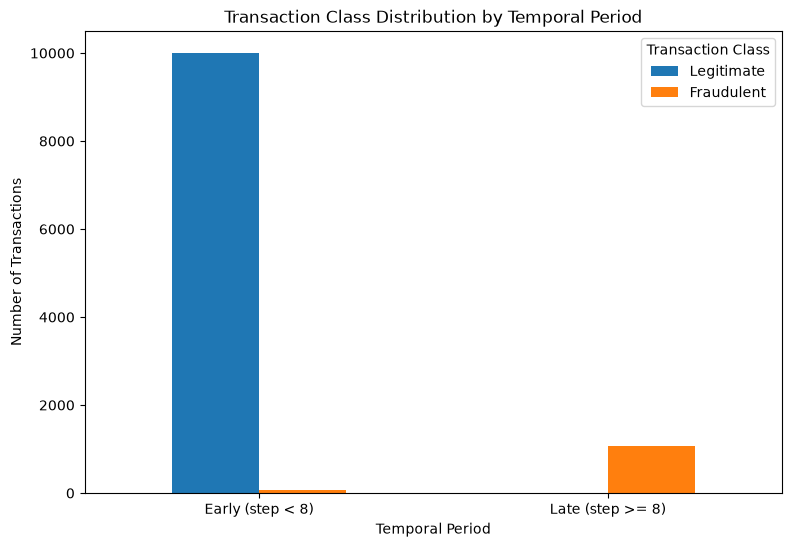

In [61]:
step_period_counts = (
    df.assign(
        period=np.where(
            df["step"] < 8,
            "Early (step < 8)",
            "Late (step >= 8)"
        )
    ).groupby(["period", "isFraud"]).size()
    .unstack(fill_value=0)
)

step_period_counts.columns = [
    "Legitimate",
    "Fraudulent"
]

step_period_counts.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Transaction Class Distribution by Temporal Period")
plt.xlabel("Temporal Period")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.legend(title="Transaction Class")

plt.show()

In [62]:
1064/1142 * 100

93.16987740805604

<mark style="background-color:lightblue">~93.17% </mark>of all fraud trans occur in the step >= 8 period

<span style="color:lightgreen">1064 </span><span>transactions after STEP 8</span><br>
<span style="color:lightgreen">+ 78 </span>transactions before STEP 8</span><br>
<span style="color:yellow">= 1,142 total fraud</span>

"step" appears to be strongly associated with the target in this dataset, but this relationship may represent a simulation/data-generation artifact rather than a generalizable fraud signal.

<span style="color:skyblue"><b>EDA Finding 8:</b></span>
-  Don't use raw step as a predictive feature
- (type->large amount->balance depletion->account behavior) is better than (step>=8 -> FRAUD)

##### <span style="color:yellow">Type by Period Analysis</span>

In [63]:
# type by period analysis

period_type_analysis = (
    df.assign(
        period=np.where(
            df["step"] < 8,
            "Early (step < 8)",
            "Late (step >= 8)"
        )
    )
    .groupby(["period", "type"])
    .size()
    .unstack(fill_value=0)
)

period_type_analysis

type,CASH_IN,CASH_OUT,DEBIT,PAYMENT,TRANSFER
period,,,,,
Early (step < 8),1951,1333,346,5510,938
Late (step >= 8),0,538,0,0,526


In [64]:
period_type_percentage = (
    period_type_analysis
    .div(period_type_analysis.sum(axis=1), axis=0) * 100
)

period_type_percentage.round(2)

type,CASH_IN,CASH_OUT,DEBIT,PAYMENT,TRANSFER
period,,,,,
Early (step < 8),19.36,13.23,3.43,54.67,9.31
Late (step >= 8),0.00,50.56,0.00,0.00,49.44


In [65]:
pd.crosstab(
    [
        np.where(
            df["step"] < 8,
            "Early (step < 8)",
            "Late (step >= 8)"
        ),
        df["type"]
    ],
    df["isFraud"],
    margins=True
)

isFraud                        0     1    All
row_0            type                        
Early (step < 8) CASH_IN    1951     0   1951
                 CASH_OUT   1293    40   1333
                 DEBIT       346     0    346
                 PAYMENT    5510     0   5510
                 TRANSFER    900    38    938
Late (step >= 8) CASH_OUT      0   538    538
                 TRANSFER      0   526    526
All                        10000  1142  11142

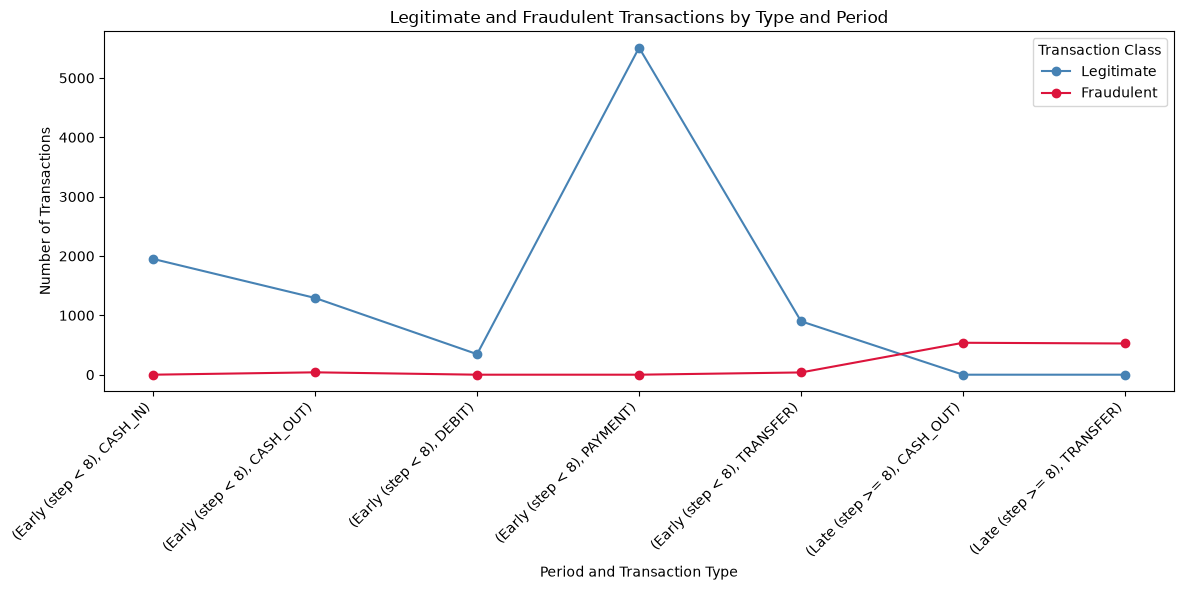

In [66]:
type_period_fraud_counts = pd.crosstab(
    [
        np.where(
            df["step"] < 8,
            "Early (step < 8)",
            "Late (step >= 8)"
        ),
        df["type"]
    ],
    df["isFraud"]
)

type_period_fraud_counts.columns = ["Legitimate", "Fraudulent"]

ax = type_period_fraud_counts.plot(
    kind="line",
    figsize=(12, 6),
    color=["steelblue", "crimson"],
    marker="o"
)

#plt.yscale("symlog")

ax.set_title("Legitimate and Fraudulent Transactions by Type and Period")
ax.set_xlabel("Period and Transaction Type")
ax.set_ylabel("Number of Transactions")
ax.legend(title="Transaction Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

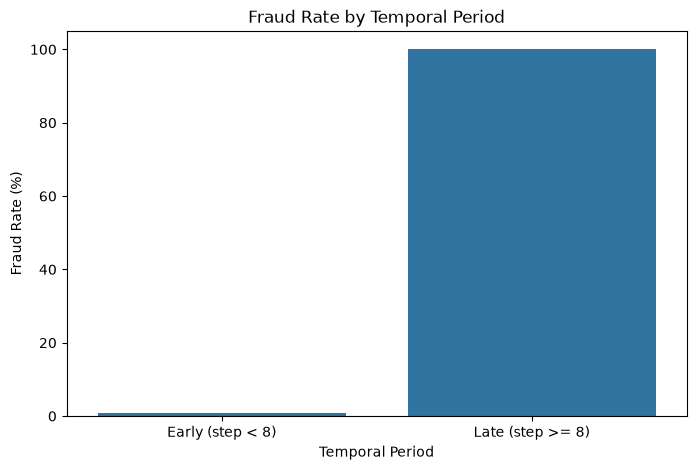

In [67]:
# Fraud rate by period

period_fraud_rate = (
    df.assign(
        period=np.where(
            df["step"] < 8,
            "Early (step < 8)",
            "Late (step >= 8)"
        )
    ).groupby("period")["isFraud"].mean().mul(100)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=period_fraud_rate.index,
    y=period_fraud_rate.values
)

plt.title("Fraud Rate by Temporal Period")
plt.xlabel("Temporal Period")
plt.ylabel("Fraud Rate (%)")

plt.show()

```mermaid
flowchart TD
    A[STEP] --- B{< 8}
    A --- C{>= 8}
    B --> D(CASH_IN, CASH_OUT, DEBIT, PAYMENT, TRANSFER)
    C --> E(CASH_OUT,TRANSFER)
    E --> F[Fraud generating period]
    F --> G[100% observed fraud]
```


The dataset undergoes a major distributional shift at step 8: the transaction mix changes from five transaction types to exclusively CASH_OUT and TRANSFER, and all transactions in the later period are labeled fraudulent.

##### <span style="color:yellow">Account Behavior Analysis</span>

In [68]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [69]:
df["nameOrig"].nunique()

11142

In [70]:

df["nameDest"].nunique() # some destinations are repeated

7508

In [71]:
origin_summary = {
    "Total Transactions": len(df),
    "Unique Origin Accounts": df["nameOrig"].nunique(),
    "Repeated Destination Transactions": (
        len(df) - df["nameOrig"].nunique()
    ),
    "Origin Reuse Rate (%)": (
        1 - df["nameOrig"].nunique() / len(df)
    ) * 100
}

origin_summary

{'Total Transactions': 11142,
 'Unique Origin Accounts': 11142,
 'Repeated Destination Transactions': 0,
 'Origin Reuse Rate (%)': 0.0}

In [72]:
destination_summary = {
    "Total Transactions": len(df),
    "Unique Destination Accounts": df["nameDest"].nunique(),
    "Repeated Destination Transactions": (
        len(df) - df["nameDest"].nunique()
    ),
    "Origin Reuse Rate (%)": (
        1 - df["nameDest"].nunique() / len(df)
    ) * 100
}

destination_summary

{'Total Transactions': 11142,
 'Unique Destination Accounts': 7508,
 'Repeated Destination Transactions': 3634,
 'Origin Reuse Rate (%)': 32.61532938431161}

In [73]:
# dest trans frequency

destination_frequency = (
    df["nameDest"].value_counts().rename("transaction_count")
)

destination_frequency

nameDest
C985934102     62
C1590550415    52
C1286084959    50
C1899073220    44
C977993101     44
               ..
M1762378078     1
M175822565      1
M1170399398     1
M542598487      1
M609545864      1
Name: transaction_count, Length: 7508, dtype: int64

In [74]:
destination_frequency.describe()

count    7508.000000
mean        1.484017
std         2.932187
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        62.000000
Name: transaction_count, dtype: float64

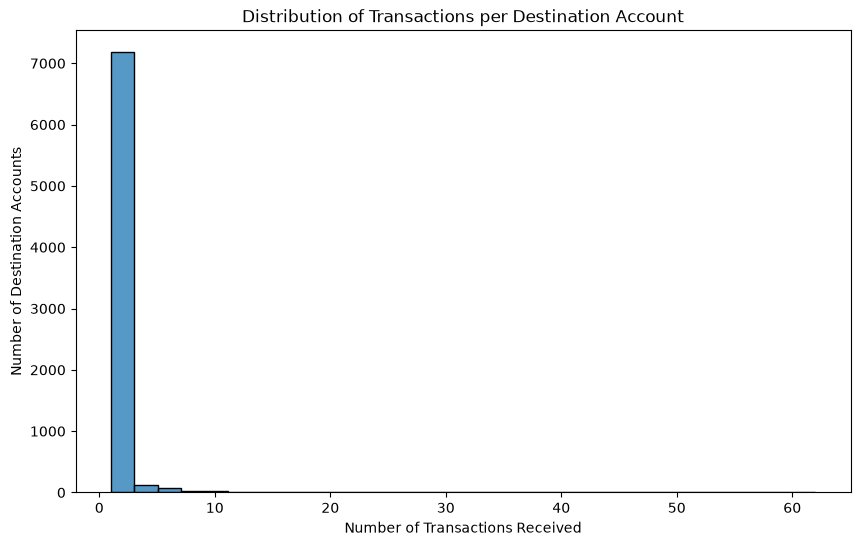

In [75]:
plt.figure(figsize=(10, 6))

sns.histplot(
    destination_frequency,
    bins=30
)

# plt.yscale("symlog")

plt.title("Distribution of Transactions per Destination Account")
plt.xlabel("Number of Transactions Received")
plt.ylabel("Number of Destination Accounts")

plt.show()

In [76]:
# Top dest accounts

top_destinations = (
    destination_frequency.head(20).reset_index()
)

top_destinations.columns = [
    "Destination Account",
    "Transaction Count"
]

top_destinations

,Destination Account,Transaction Count
0,C985934102,62
1,C1590550415,52
2,C1286084959,50
3,C1899073220,44
4,C977993101,44
5,C451111351,43
6,C1782113663,43
7,C2083562754,41
8,C1789550256,40
9,C1816757085,40


In [77]:
df["destination_account_type"] = (
    df["nameDest"]
    .str[0]
    .map({
        "C": "Customer",
        "M": "Merchant"
    })
)

df["destination_account_type"].value_counts(dropna=False)

destination_account_type
Customer    5632
Merchant    5510
Name: count, dtype: int64

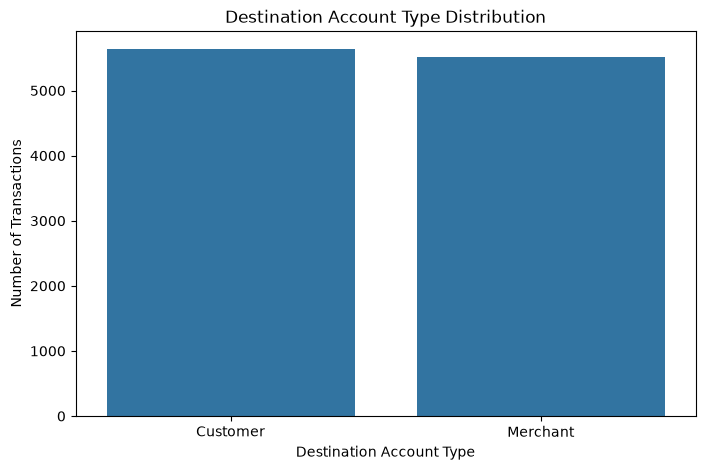

In [78]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="destination_account_type"
)

plt.title("Destination Account Type Distribution")
plt.xlabel("Destination Account Type")
plt.ylabel("Number of Transactions")

plt.show()

In [79]:
destination_type_distribution = (
    df["destination_account_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

destination_type_distribution

destination_account_type
Customer    50.55
Merchant    49.45
Name: proportion, dtype: float64

In [80]:
# Fraud by dest account type

destination_fraud_analysis = (
    df.groupby("destination_account_type")["isFraud"]
      .agg(["count", "sum", "mean"])
)

destination_fraud_analysis.columns = [
    "Total Transactions",
    "Fraudulent Transactions",
    "Fraud Rate"
]

destination_fraud_analysis["Fraud Rate (%)"] = (
    destination_fraud_analysis["Fraud Rate"] * 100
).round(2)

destination_fraud_analysis

,Total Transactions,Fraudulent Transactions,Fraud Rate,Fraud Rate (%)
destination_account_type,,,,
Customer,5632,1142,0.20277,20.28
Merchant,5510,0,0.00000,0.00


In [81]:
destination_activity = (
    df.groupby("nameDest")
      .agg(
          transaction_count=("nameDest", "count"),
          total_amount=("amount", "sum"),
          average_amount=("amount", "mean"),
          max_amount=("amount", "max")
      )
      .sort_values(
          "transaction_count",
          ascending=False
      )
)

destination_activity.head(20)

,transaction_count,total_amount,average_amount,max_amount
nameDest,,,,
C985934102,62,18888987.93,304661.095645,1946101.41
C1590550415,52,29579451.08,568835.597692,2545478.01
C1286084959,50,17981492.66,359629.853200,1571619.71
C977993101,44,9298512.91,211329.838864,896122.80
C1899073220,44,12709555.67,288853.537955,1541543.10
C1782113663,43,13585853.78,315950.087907,1918461.70
C451111351,43,16118094.39,374839.404419,1628887.72
C2083562754,41,11618917.62,283388.234634,1675530.06
C1816757085,40,13686388.28,342159.707000,2107293.71


In [82]:
repeated_destinations = (
    destination_frequency[destination_frequency > 1]
)

print(
    "Destination accounts appearing more than once:",
    len(repeated_destinations)
)

print(
    "Transactions associated with repeated destinations:",
    repeated_destinations.sum()
)

Destination accounts appearing more than once: 601
Transactions associated with repeated destinations: 4235


In [83]:
for threshold in [1, 2, 5, 10, 20, 50]:
    
    count = (
        destination_frequency >= threshold
    ).sum()
    
    print(
        f"Destinations with >= {threshold} transactions: "
        f"{count}"
    )

Destinations with >= 1 transactions: 7508
Destinations with >= 2 transactions: 601
Destinations with >= 5 transactions: 264
Destinations with >= 10 transactions: 106
Destinations with >= 20 transactions: 50
Destinations with >= 50 transactions: 3


In [84]:
eda_df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,origin_balance_change,destination_balance_change,origin_balance_error,destination_balance_error,amount_to_origin_balance_ratio,origin_change_amount_difference,abs_origin_change_amount_difference,balance_amount_match
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,181.0,0.0,0.0,181.0,1.0,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,181.0,-21182.0,0.0,21363.0,1.0,0.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1,2806.0,0.0,0.0,2806.0,1.0,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1,2806.0,-26202.0,0.0,29008.0,1.0,0.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1,20128.0,0.0,0.0,20128.0,1.0,0.0,0.0,1


In [85]:
# how many transactions each desst recieves

destination_count_map = (
    df["nameDest"].value_counts()
)

eda_df["destination_transaction_count"] = (
    eda_df["nameDest"]
    .map(destination_count_map)
)

In [86]:
destination_activity_by_fraud = eda_df.groupby("isFraud")[
    "destination_transaction_count"
].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
])

destination_activity_by_fraud

,count,mean,median,std,min,max
isFraud,,,,,,
0,10000,7.961000,1.0,12.723674,1,62
1,1142,1.285464,1.0,2.117276,1,36


In [87]:
destination_fraud_summary = (
    df.groupby("nameDest")
      .agg(
          transaction_count=("nameDest", "size"),
          fraud_count=("isFraud", "sum"),
          total_amount=("amount", "sum")
      )
)

In [88]:
destination_fraud_summary

,transaction_count,fraud_count,total_amount
nameDest,,,
C1002031672,1,1,22877.00
C1002469873,1,1,339275.64
C1003872245,1,0,603999.01
C1005460442,1,1,400157.86
C100555887,2,0,69958.98
...,...,...,...
M998458782,1,0,3088.09
M998935228,1,0,13239.13
M998983750,1,0,980.14


In [89]:
destination_fraud_summary["fraud_rate"] = (
    destination_fraud_summary["fraud_count"] /
    destination_fraud_summary["transaction_count"]
)

In [90]:
destination_fraud_summary.sort_values(
    "fraud_count",
    ascending=False
)

,transaction_count,fraud_count,total_amount,fraud_rate
nameDest,,,,
C410033330,6,2,418555.31,0.333333
C52390890,2,2,2662695.58,1.000000
C104038589,2,2,2202769.97,1.000000
C1981613973,2,2,7265501.67,1.000000
C200064275,2,2,8847.00,1.000000
...,...,...,...,...
M1455204443,1,0,3605.26,0.000000
M1455066764,1,0,3043.29,0.000000
M1455019071,1,0,4026.05,0.000000


<span style="color:skyblue"><b>EDA Finding 9:</b></span>
- Median= 1-> most destination accounts appear only once(See cell 128)
- nameDest itself should not be fed directly into a normal ML model<br>
because they are identifiers, not meaningful numerical quantities.
-- can potentially derive behavioral features such as:<br>
destination_transaction_count<br>
destination_total_amount<br>
destination_average_amount<br>

-- For real-time fraud detection, those features must be calculated using only information available before the current transaction
- Every fraudulent transaction in our dataset goes to: Customer destination, no fraudulent transaction goes to a merchant destination.
- "destination_activity" tells us that some destinations receive many transactions.

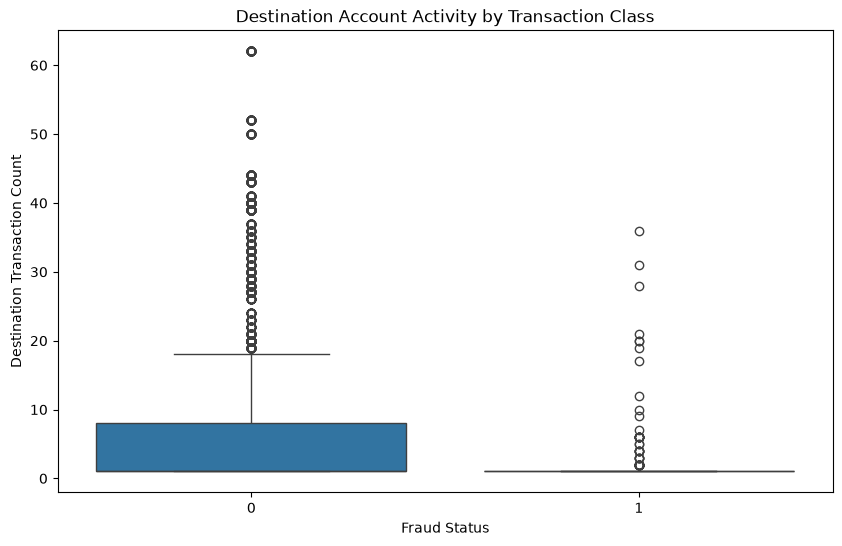

In [91]:
# comparing activity distributions

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=eda_df,
    x="isFraud",
    y="destination_transaction_count"
)

plt.title(
    "Destination Account Activity by Transaction Class"
)

# plt.yscale("log")

plt.xlabel("Fraud Status")
plt.ylabel("Destination Transaction Count")

plt.show()

In [92]:
eda_df["destination_activity_bucket"] = pd.cut(
    eda_df["destination_transaction_count"],
    bins=[0, 1, 2, 5, 10, 25, float("inf")],
    labels=[
        "1",
        "2",
        "3-5",
        "6-10",
        "11-25",
        "26+"
    ]
)

In [93]:
destination_activity_fraud = (
    eda_df.groupby(
        "destination_activity_bucket",
        observed=False
    )["isFraud"]
    .agg(["count", "sum", "mean"])
)

destination_activity_fraud.columns = [
    "Total Transactions",
    "Fraudulent Transactions",
    "Fraud Rate"
]

destination_activity_fraud["Fraud Rate (%)"] = (
    destination_activity_fraud["Fraud Rate"] * 100
).round(2)

destination_activity_fraud

,Total Transactions,Fraudulent Transactions,Fraud Rate,Fraud Rate (%)
destination_activity_bucket,,,,
1,6907,1078,0.156074,15.61
2,334,32,0.095808,9.58
3-5,873,11,0.012600,1.26
6-10,820,12,0.014634,1.46
11-25,921,6,0.006515,0.65
26+,1287,3,0.002331,0.23


In [94]:
# type-dest accnt 

top_dest_type_mix = (
    df.groupby(["nameDest", "type"])
      .size()
      .unstack(fill_value=0)
)

top_dest_type_mix["total_transactions"] = (
    top_dest_type_mix.sum(axis=1)
)

top_dest_type_mix.sort_values(
    "total_transactions",
    ascending=False
).head(20)

type,CASH_IN,CASH_OUT,DEBIT,PAYMENT,TRANSFER,total_transactions
nameDest,,,,,,
C985934102,31,16,2,0,13,62
C1590550415,25,12,0,0,15,52
C1286084959,21,14,1,0,14,50
C977993101,20,16,2,0,6,44
C1899073220,15,18,1,0,10,44
C1782113663,21,13,0,0,9,43
C451111351,21,9,1,0,12,43
C2083562754,16,16,1,0,8,41
C1816757085,24,9,1,0,6,40


```mermaid
flowchart TD
    A[TRANSACTION] --- B(Type)
    A --- C(Balance Behavior)
    A --- D(Destination)
    B --> E(CASH_IN, DEBIT, PAYMENT)
    B --> F(CASH_OUT,TRANSFER)
    C --> G(Balance Match)
    D --> H(Customer)
    D --> I(Merchant)
    F ==> J[100% observed fraud]
    G ==> J
    H ==> J
    E ==> K[0 observed fraud]
    I ==> K
```

In [95]:
eda_df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,origin_balance_change,destination_balance_change,origin_balance_error,destination_balance_error,amount_to_origin_balance_ratio,origin_change_amount_difference,abs_origin_change_amount_difference,balance_amount_match,destination_transaction_count,destination_activity_bucket
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,181.0,0.0,0.0,181.0,1.0,0.0,0.0,1,3,3-5
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,181.0,-21182.0,0.0,21363.0,1.0,0.0,0.0,1,1,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1,2806.0,0.0,0.0,2806.0,1.0,0.0,0.0,1,1,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1,2806.0,-26202.0,0.0,29008.0,1.0,0.0,0.0,1,1,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1,20128.0,0.0,0.0,20128.0,1.0,0.0,0.0,1,1,1


##### <span style="color:yellow">Destination Balance Analysis</span>

In [96]:
destination_balance_stats = (
    eda_df.groupby("isFraud")[
        [
            "oldbalanceDest",
            "newbalanceDest"
        ]
    ]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

destination_balance_stats.round(2)

oldbalanceDest                                                 \
                 count       mean median         std  min         max   
isFraud                                                                 
0                10000  938086.81    0.0  2683396.63  0.0  19500000.0   
1                 1142  452866.12    0.0  1662232.09  0.0  33000000.0   

        newbalanceDest                                                     
                 count        mean    median         std  min         max  
isFraud                                                                    
0                10000  1106097.43      0.00  3038860.66  0.0  22600000.0  
1                 1142  1077940.47  13798.76  2434195.13  0.0  34600000.0

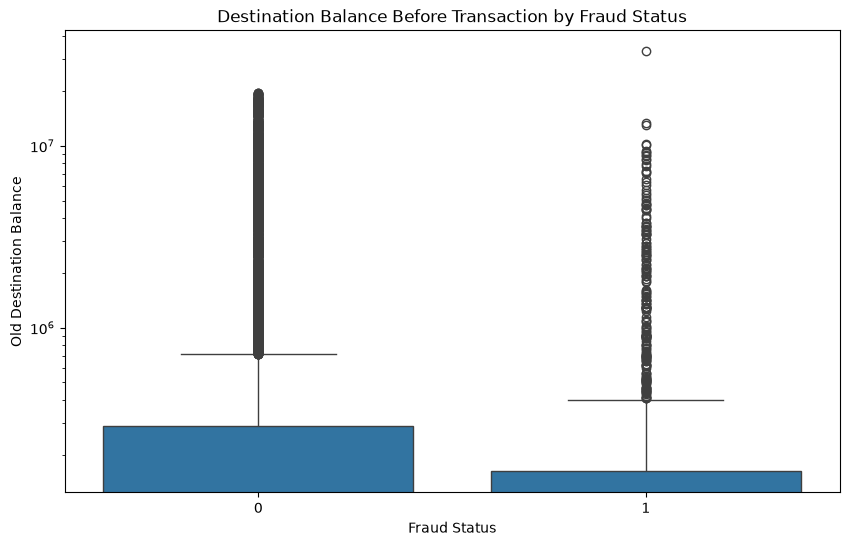

In [97]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=eda_df,
    x="isFraud",
    y="oldbalanceDest"
)

plt.yscale("log")

plt.title("Destination Balance Before Transaction by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Old Destination Balance")

plt.show()

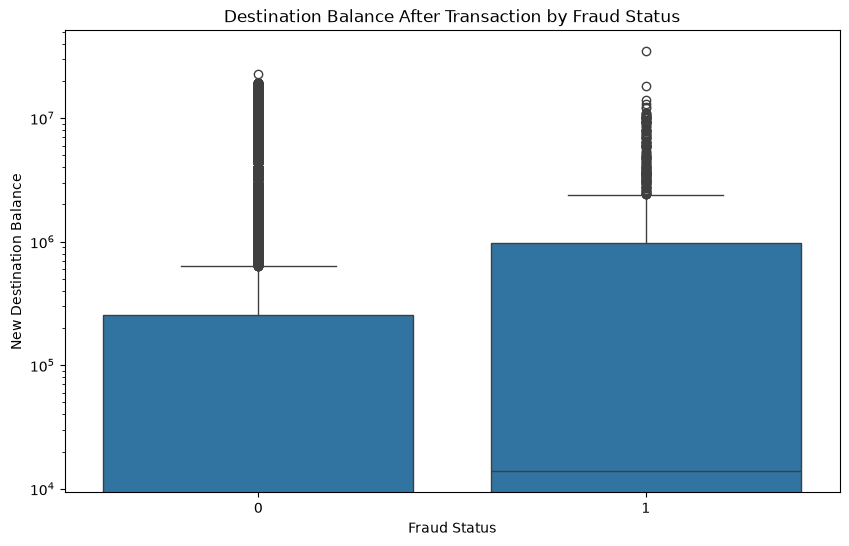

In [98]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=eda_df,
    x="isFraud",
    y="newbalanceDest"
)

plt.yscale("log")

plt.title("Destination Balance After Transaction by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("New Destination Balance")

plt.show()

In [99]:
destination_balance_summary = (
    eda_df.groupby("isFraud")[
        [
            "oldbalanceDest",
            "newbalanceDest",
            "destination_balance_change"
        ]
    ]
    .median()
)

destination_balance_summary

,oldbalanceDest,newbalanceDest,destination_balance_change
isFraud,,,
0,0.0,0.000,0.000
1,0.0,13798.765,3733.035


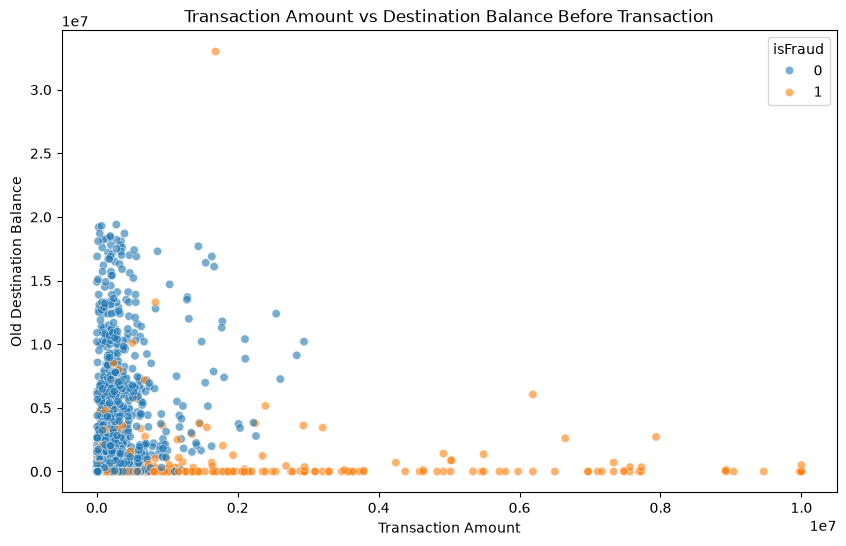

In [100]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=eda_df.sample(
        min(5000, len(eda_df)),
        random_state=42
    ),
    x="amount",
    y="oldbalanceDest",
    hue="isFraud",
    alpha=0.6
)

# plt.xscale("log")
# plt.yscale("symlog")

plt.title(
    "Transaction Amount vs Destination Balance Before Transaction"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Old Destination Balance")

plt.show()

In [101]:
# dest balance utilization
# How large is the incoming transaction relative to the destination's existing balance

eda_df["amount_to_destination_balance_ratio"] = np.where(
    eda_df["oldbalanceDest"] > 0,
    eda_df["amount"] / eda_df["oldbalanceDest"],
    0
)

In [102]:
destination_ratio_stats = (
    eda_df.groupby("isFraud")[
        "amount_to_destination_balance_ratio"
    ]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

destination_ratio_stats

,count,mean,median,std,min,max
isFraud,,,,,,
0,10000,6.060888,0.0,320.869214,0.0,31594.141429
1,1142,12.074096,0.0,156.649059,0.0,4078.444412


Project description explicitly noted that balance information is not available for customers whose destination IDs begin with M (merchants).
<br>

zeros in destination-balance columns do not necessarily mean the destination account had zero money.

In [103]:
destination_zero_analysis = (
    eda_df.groupby("isFraud")[
        [
            "oldbalanceDest",
            "newbalanceDest"
        ]
    ]
    .apply(
        lambda x: (x == 0).mean() * 100
    )
)

destination_zero_analysis.round(2)

,oldbalanceDest,newbalanceDest
isFraud,,
0,56.77,58.38
1,63.75,48.60


In [104]:
eda_df["destination_account_type"] = (
    eda_df["nameDest"]
    .str[0]
    .map({
        "C": "Customer",
        "M": "Merchant"
    })
)

In [105]:
zero_balance_by_type = (
    eda_df.groupby("destination_account_type")[
        [
            "oldbalanceDest",
            "newbalanceDest"
        ]
    ]
    .apply(
        lambda x: (x == 0).mean() * 100
    )
)

zero_balance_by_type.round(2)

,oldbalanceDest,newbalanceDest
destination_account_type,,
Customer,15.89,15.68
Merchant,100.00,100.00


In [106]:
eda_df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,origin_balance_change,destination_balance_change,origin_balance_error,destination_balance_error,amount_to_origin_balance_ratio,origin_change_amount_difference,abs_origin_change_amount_difference,balance_amount_match,destination_transaction_count,destination_activity_bucket,amount_to_destination_balance_ratio,destination_account_type
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,181.0,0.0,0.0,181.0,1.0,0.0,0.0,1,3,3-5,0.000000,Customer
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,181.0,-21182.0,0.0,21363.0,1.0,0.0,0.0,1,1,1,0.008545,Customer
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1,2806.0,0.0,0.0,2806.0,1.0,0.0,0.0,1,1,1,0.000000,Customer
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1,2806.0,-26202.0,0.0,29008.0,1.0,0.0,0.0,1,1,1,0.107091,Customer
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1,20128.0,0.0,0.0,20128.0,1.0,0.0,0.0,1,1,1,0.000000,Customer


In [107]:
eda_df.groupby("isFraud")[
        [
            "destination_balance_change"
        ]
    ].agg([
        "count",
        "mean",
        "median",
]).round(2)

destination_balance_change                    
                             count       mean   median
isFraud                                               
0                            10000  168010.62     0.00
1                             1142  625074.35  3733.04

|"OldbalanceDest" Class|Mean|Median|
|---|---|---|
|Legitimate|₹938,086.81|₹0|
|Fraud|₹452,866.12|₹0|

<span style="color:skyblue"><b>EDA Finding 10:</b></span>
- Both legitimate and fraudulent transactions have a median oldbalanceDest of ₹0. That means oldbalanceDest doesn't provide a clean separation by itself. (Keep as candidate signal, not major fraud signal)

|"NewbalanceDest" Class|Mean|Median|
|---|---|---|
|Legitimate|₹1,106,097|₹0|
|Fraud|₹1,077,940|₹13,798.76|

- although destination balances are heavily zero-inflated, fraudulent transactions have somewhat more positive post-transaction destination balances.

- That means the distribution is highly right-skewed: most legitimate transactions have little/no destination balance change

- Within this dataset, the observed destination_balance_change has a substantially higher mean and median among fraudulent transactions than among legitimate transactions.

In [108]:
# dest balance error 

destination_error_stats = (
    eda_df.groupby("isFraud")[
        "destination_balance_error"
    ]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

destination_error_stats.round(2)

,count,mean,median,std,min,max
isFraud,,,,,,
0,10000,-66670.89,6605.92,985282.45,-17919963.77,13230407.77
1,1142,567554.59,9439.94,1593694.75,-8875516.29,10000000.00


In [109]:
destination_error_percentiles = (
    eda_df.groupby("isFraud")[
        "destination_balance_error"
    ]
    .quantile([
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99
    ])
    .unstack()
)

destination_error_percentiles.round(2)

,0.01,0.05,0.25,0.50,0.75,0.95,0.99
isFraud,,,,,,,
0,-3823429.38,-788016.32,1117.91,6605.92,29932.37,602800.96,1206138.75
1,-614098.57,-26691.29,0.00,9439.94,353246.50,3510816.01,8995114.86


In [110]:
destination_error_corr = (
    eda_df[
        [
            "amount",
            "oldbalanceDest",
            "newbalanceDest",
            "destination_balance_change",
            "destination_balance_error"
        ]
    ]
    .corr()
)

destination_error_corr.round(3)

,amount,oldbalanceDest,newbalanceDest,destination_balance_change,destination_balance_error
amount,1.000,0.094,0.227,0.388,0.302
oldbalanceDest,0.094,1.000,0.929,0.151,-0.090
newbalanceDest,0.227,0.929,1.000,0.507,-0.364
destination_balance_change,0.388,0.151,0.507,1.000,-0.762
destination_balance_error,0.302,-0.090,-0.364,-0.762,1.000


| Feature | Decision | Reason |
|---|---|---|
| oldbalanceDest | <span style="color:yellow">Candidate</span> | Strongly correlated with new balance |
| newbalanceDest | <span style="color:yellow">Candidate</span> | Strongly correlated with old balance |
| destination_balance_change | <span style="color:lightgreen">Strong candidate</span> | Strong fraud-vs-legitimate distribution difference |
| destination_balance_error | <span style="color:yellow">Candidate</span> | Distinct information but correlated with change |
| amount_to_destination_balance_ratio | <span style="color:red">Exclude</span> | Zero-inflated + extreme ratios |
| nameDest | <span style="color:red">Exclude raw</span> | High-cardinality identifier |
| destination_account_type | <span style="color:yellow">Candidate</span> | Strong observed association |

## Complete EDA:
- <b>Class Distribution</b> - 10.25% Fraud
- <b>Transaction type</b> - TRANSFER, CASH_OUT
- <b>Amount</b> - Fraud transactions have larger amounts
- <b>Time</b> - (step>=8) 100% Fraud
- <b>Origin balances</b> - Strong relationship between transaction amount and origin-balance change.
- <b> Destination type</b> - Customer(20.28% fraud), Merchant(0%)
- <b> Account Behavior</b> - Most destination accounts occur once, but some are reused up to 62 times.
- <b> Destinaton balances</b> - Strong skew/zero inflation, especially for Merchants
- <b> Balance Consistency</b> - Fraud has a much stronger balance-match pattern

### Step 6 - Feature Engineering

| Original / Derived Feature | Decision | Why |
|---|---|---|
| amount | <span style="color:green">Keep</span> | Core transaction signal |
| type | <span style="color:green">Keep</span> | Extremely strong fraud association |
| oldbalanceOrg | <span style="color:green">Keep</span> | Origin financial state |
| newbalanceOrig | <span style="color:green">Keep</span> | Origin financial state |
| oldbalanceDest | <span style="color:#d4a017">Keep candidate</span> | Useful, but highly correlated with new balance |
| newbalanceDest | <span style="color:#d4a017">Keep candidate</span> | Post-transaction state |
| origin_balance_change | <span style="color:green">Keep</span> | Measures money leaving origin |
| destination_balance_change | <span style="color:green">Keep</span> | Strong fraud-related signal |
| origin_balance_error | <span style="color:#d4a017">Keep candidate</span> | Measures balance inconsistency |
| destination_balance_error | <span style="color:#d4a017">Keep candidate</span> | Useful but correlated with destination change |
| step | <span style="color:red">Primary model</span> | Dataset-specific shortcut |
| nameOrig | <span style="color:red">Drop</span> | Every origin is unique |
| nameDest | <span style="color:red">Raw</span> | High-cardinality identifier |
| destination_account_type | <span style="color:green">Candidate</span> | Strong observed association |
| raw amount_to_destination_balance_ratio | <span style="color:red">Drop</span> | Extremely unstable due to zero balances |
| historical destination activity | <span style="color:#d4a017">Later</span> | Potentially powerful, but must be point-in-time safe |

In [111]:
# creating clean modeling dataframe

model_df = df.copy()

print("Shape:", model_df.shape)
model_df.head()

Shape: (11142, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,destination_account_type
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,Customer
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,Customer
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1,Customer
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1,Customer
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1,Customer


In [112]:
model_df["destination_account_type"] = (
    model_df["nameDest"]
    .str[0]
    .map({
        "C": "Customer",
        "M": "Merchant"
    })
)

model_df["destination_account_type"].value_counts(
    dropna=False
)

destination_account_type
Customer    5632
Merchant    5510
Name: count, dtype: int64

In [113]:
# balance change features

model_df["origin_balance_change"] = (
    model_df["oldbalanceOrg"]
    - model_df["newbalanceOrig"]
) # money leaving account

model_df["destination_balance_change"] = (
    model_df["newbalanceDest"]
    - model_df["oldbalanceDest"]
) # money entering account

model_df["origin_balance_change"].head()

0      181.0
1      181.0
2     2806.0
3     2806.0
4    20128.0
Name: origin_balance_change, dtype: float64

In [114]:
# balance error features

model_df["origin_balance_error"] = (
    model_df["origin_balance_change"]
    - model_df["amount"]
)

model_df["destination_balance_error"] = (
    model_df["amount"]
    - model_df["destination_balance_change"]
)

In [115]:
model_df["abs_origin_balance_error"] = (
    model_df["origin_balance_error"].abs()
)

model_df["abs_destination_balance_error"] = (
    model_df["destination_balance_error"].abs()
)

In [116]:
model_df["origin_balance_match"] = (
    model_df["abs_origin_balance_error"] <= 1
).astype(int)

model_df["origin_balance_match"].value_counts(dropna=False) 
# 1 = balance change ~= amount, 0 = doesn't match

origin_balance_match
0    6013
1    5129
Name: count, dtype: int64

In [117]:
model_df["destination_balance_match"] = (
    model_df["abs_destination_balance_error"] <= 1
).astype(int)

model_df["destination_balance_match"].value_counts(dropna=False) 

destination_balance_match
0    10001
1     1141
Name: count, dtype: int64

In [118]:
model_df["log_amount"] = np.log1p(
    model_df["amount"]
)
# transformation to handle zeros 
# log1p(x) = log(x + 1)

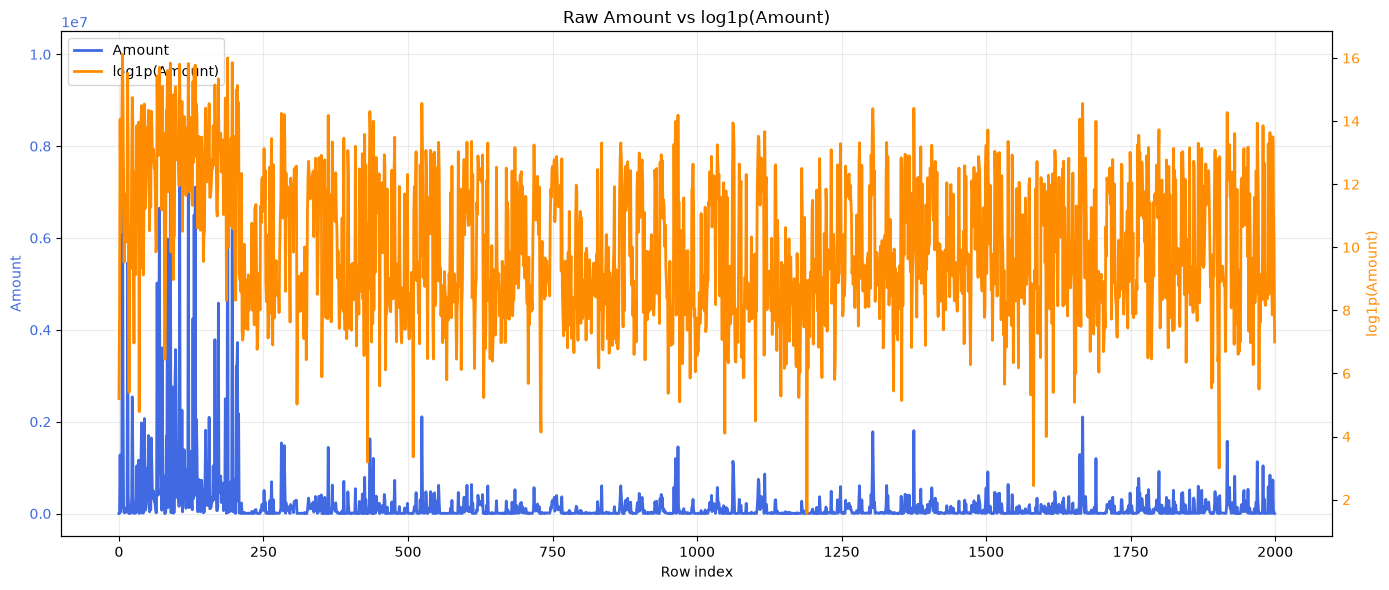

In [119]:
# Compare raw amount vs log-transformed amount on the same chart
sample_df = (
    model_df.sample(
        n=min(2000, len(model_df)),
        random_state=42
    )
    .sort_index()
    .reset_index(drop=True)
)

fig, ax1 = plt.subplots(figsize=(14, 6))

line1 = ax1.plot(
    sample_df.index,
    sample_df["amount"],
    color="royalblue",
    linewidth=2,
    label="Amount"
)
ax1.set_xlabel("Row index")
ax1.set_ylabel("Amount", color="royalblue")
ax1.tick_params(axis="y", labelcolor="royalblue")
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
line2 = ax2.plot(
    sample_df.index,
    sample_df["log_amount"],
    color="darkorange",
    linewidth=2,
    label="log1p(Amount)"
)
ax2.set_ylabel("log1p(Amount)", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Raw Amount vs log1p(Amount)")
plt.tight_layout()
plt.show()

In [120]:
model_df["amount_to_origin_balance_ratio"] = np.where(
    model_df["oldbalanceOrg"] > 0,
    model_df["amount"] / model_df["oldbalanceOrg"],
    0
)

model_df["amount_to_origin_balance_ratio"]

0        1.000000
1        1.000000
2        1.000000
3        1.000000
4        1.000000
           ...   
11137    0.014763
11138    0.700272
11139    3.308749
11140    0.078605
11141    0.231103
Name: amount_to_origin_balance_ratio, Length: 11142, dtype: float64

In [121]:
# what proportion of origin balance was depleted

model_df["origin_balance_depletion_ratio"] = np.where(
    model_df["oldbalanceOrg"] > 0,
    model_df["origin_balance_change"]
    / model_df["oldbalanceOrg"],
    0
)

model_df["origin_balance_depletion_ratio"]

0        1.000000
1        1.000000
2        1.000000
3        1.000000
4        1.000000
           ...   
11137    0.014763
11138    0.700272
11139    1.000000
11140    0.078605
11141    0.231103
Name: origin_balance_depletion_ratio, Length: 11142, dtype: float64

In [122]:
model_df["origin_balance_zero"] = (
    model_df["oldbalanceOrg"] == 0
).astype(int)

model_df["destination_balance_zero"] = (
    model_df["oldbalanceDest"] == 0
).astype(int)

- Dropping nameOrig and nameDest (because it uses future transactions)

In [123]:
candidate_features = [
    # Transaction
    "amount",
    "log_amount",
    "type",

    # Origin balances
    "oldbalanceOrg",
    "newbalanceOrig",
    "origin_balance_change",
    "origin_balance_error",
    "abs_origin_balance_error",
    "origin_balance_match",
    "amount_to_origin_balance_ratio",
    "origin_balance_depletion_ratio",
    "origin_balance_zero",

    # Destination balances
    "oldbalanceDest",
    "newbalanceDest",
    "destination_balance_change",
    "destination_balance_error",
    "abs_destination_balance_error",
    "destination_balance_match",
    "destination_balance_zero",

    # Destination structure
    "destination_account_type"
]

In [124]:
X = model_df[candidate_features].copy()

y = model_df["isFraud"].copy()

print("Feature matrix:", X.shape)
print("Target:", y.shape)

Feature matrix: (11142, 20)
Target: (11142,)


In [125]:
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   amount                          11142 non-null  float64
 1   log_amount                      11142 non-null  float64
 2   type                            11142 non-null  object 
 3   oldbalanceOrg                   11142 non-null  float64
 4   newbalanceOrig                  11142 non-null  float64
 5   origin_balance_change           11142 non-null  float64
 6   origin_balance_error            11142 non-null  float64
 7   abs_origin_balance_error        11142 non-null  float64
 8   origin_balance_match            11142 non-null  int32  
 9   amount_to_origin_balance_ratio  11142 non-null  float64
 10  origin_balance_depletion_ratio  11142 non-null  float64
 11  origin_balance_zero             11142 non-null  int32  
 12  oldbalanceDest                  

In [126]:
X.isnull().sum()

amount                            0
log_amount                        0
type                              0
oldbalanceOrg                     0
newbalanceOrig                    0
origin_balance_change             0
origin_balance_error              0
abs_origin_balance_error          0
origin_balance_match              0
amount_to_origin_balance_ratio    0
origin_balance_depletion_ratio    0
origin_balance_zero               0
oldbalanceDest                    0
newbalanceDest                    0
destination_balance_change        0
destination_balance_error         0
abs_destination_balance_error     0
destination_balance_match         0
destination_balance_zero          0
destination_account_type          0
dtype: int64

In [127]:
np.isinf(X.select_dtypes(include=np.number)).sum()

amount                            0
log_amount                        0
oldbalanceOrg                     0
newbalanceOrig                    0
origin_balance_change             0
origin_balance_error              0
abs_origin_balance_error          0
origin_balance_match              0
amount_to_origin_balance_ratio    0
origin_balance_depletion_ratio    0
origin_balance_zero               0
oldbalanceDest                    0
newbalanceDest                    0
destination_balance_change        0
destination_balance_error         0
abs_destination_balance_error     0
destination_balance_match         0
destination_balance_zero          0
dtype: int64

In [128]:
X.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
amount,11142.0,213191.49,760065.01,2.39,4946.62,16761.26,154336.58,10000000.00
log_amount,11142.0,10.10,2.20,1.22,8.51,9.73,11.95,16.12
oldbalanceOrg,11142.0,924117.26,2143004.31,0.00,427.00,28169.50,304085.48,19900000.00
newbalanceOrig,11142.0,824957.65,2089894.17,0.00,0.00,4420.60,111412.64,13000000.00
origin_balance_change,11142.0,99159.61,752939.49,-1030100.15,0.00,1197.45,8818.03,10038991.68
origin_balance_error,11142.0,-114031.88,253962.62,-3776389.09,-113726.33,-2166.05,0.00,38991.68
abs_origin_balance_error,11142.0,114044.36,253957.02,0.00,0.00,2200.06,113726.33,3776389.09
origin_balance_match,11142.0,0.46,0.50,0.00,0.00,0.00,1.00,1.00
amount_to_origin_balance_ratio,11142.0,12.71,250.51,0.00,0.00,0.09,1.00,21761.03
origin_balance_depletion_ratio,11142.0,-0.51,32.11,-1924.68,0.00,0.05,0.93,1.00


1. amount - heavily skewed, log_amount - much more compressed [keep both candidates]

2. origin_balance_change = old-new (if +ve old>new, -ve new>old) - highly skewed

3. origin_balance_error - highly skewed

4. origin_balance_match - EDA 7 - {["abs_origin_change_amount_difference"] <= 1} (legitimate-40.18%, fraud-97.29%)

5. amount_to_origin_balance_ratio = amount/ oldbalanceOrg - (if oldbalance very small, ratio explodes)[keep as candidate, must transform]

6. origin_balance_depletion_ratio = origin_bal_change/ oldbalanceOrg (same as above) [candidate]

7. oldbalanceDest, newbalanceDest - highly skewed (Merchants have 100% zero balances in this dataset)

8. destination_balance_change - massive skew + large outliers (linear model - transformation, tree based- can handle skew) [strong candidate]

9. destination_balance_error - massive skew, correlation -0.762 with dest_balance_change [keeo both candidates]

10. destination_balance_match - mean 0.10 

11. destination_balance_zero- mean 0.57 (57% of transactions have zero oldbalanceDest)

|Healthy candidate features|Potential (but highly skewed)|Unstable Ratios|
|---|---|---|
|amount|origin_balance_error|amount_to_origin_balance_ratio|
|oldbalanceOrg|destination_balance_change|origin_balance_depletion_ratio|
|newbalanceOrig|destination_balance_error|
|origin_balance_match|
|destination_balance_match|

In [129]:
origin_ratio_analysis = (
    model_df.groupby("isFraud")[
        [
            "amount_to_origin_balance_ratio",
            "origin_balance_depletion_ratio"
        ]
    ]
    .quantile([
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99
    ])
    .unstack()
)

origin_ratio_analysis.round(4)

amount_to_origin_balance_ratio                                        \
                                  0.01 0.05    0.25    0.50    0.75     0.95   
isFraud                                                                        
0                                  0.0  0.0  0.0008  0.0582  0.4361  15.0802   
1                                  0.0  1.0  1.0000  1.0000  1.0000   1.0000   

                  origin_balance_depletion_ratio                               \
             0.99                           0.01    0.05 0.25    0.50    0.75   
isFraud                                                                         
0        155.3764                        -1.5393 -0.0967  0.0  0.0185  0.3663   
1          1.0000                         0.0000  1.0000  1.0  1.0000  1.0000   

                   
        0.95 0.99  
isFraud            
0        1.0  1.0  
1        1.0  1.0

In [130]:
# count extreme ratios

ratio_extreme_counts = ({
    "amount_to_origin_ratio_>_10": (
        model_df["amount_to_origin_balance_ratio"] > 10
    ).sum(),

    "amount_to_origin_ratio_>_100": (
        model_df["amount_to_origin_balance_ratio"] > 100
    ).sum(),

    "depletion_ratio_>_1": (
        model_df["origin_balance_depletion_ratio"] > 1
    ).sum(),

    "depletion_ratio_<_-1": (
        model_df["origin_balance_depletion_ratio"] < -1
    ).sum()
})

ratio_extreme_counts = pd.DataFrame.from_dict(ratio_extreme_counts, orient="index")

ratio_extreme_counts

,0
amount_to_origin_ratio_>_10,659
amount_to_origin_ratio_>_100,130
depletion_ratio_>_1,0
depletion_ratio_<_-1,128


In [131]:
# log transformed amount/origin ratio

model_df["log_amount_to_origin_ratio"] = np.log1p(
    model_df["amount_to_origin_balance_ratio"]
)

model_df["log_amount_to_origin_ratio"]

0        0.693147
1        0.693147
2        0.693147
3        0.693147
4        0.693147
           ...   
11137    0.014655
11138    0.530788
11139    1.460648
11140    0.075669
11141    0.207911
Name: log_amount_to_origin_ratio, Length: 11142, dtype: float64

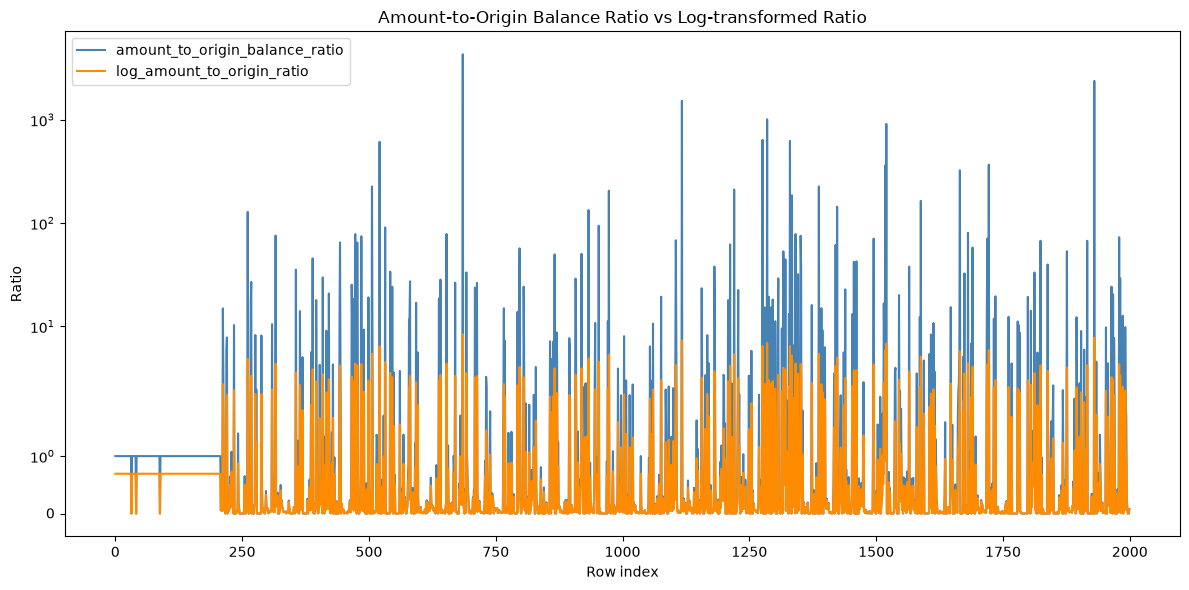

In [132]:
sample = model_df.sample(n=min(2000, len(model_df)), random_state=42).sort_index().reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.plot(sample.index, sample["amount_to_origin_balance_ratio"], label="amount_to_origin_balance_ratio", color="steelblue")
plt.plot(sample.index, sample["log_amount_to_origin_ratio"], label="log_amount_to_origin_ratio", color="darkorange")

plt.yscale("symlog")

plt.title("Amount-to-Origin Balance Ratio vs Log-transformed Ratio")
plt.xlabel("Row index")
plt.ylabel("Ratio")
plt.legend()
plt.tight_layout()
plt.show()

In [133]:
model_df["clipped_origin_depletion_ratio"] = (
    model_df["origin_balance_depletion_ratio"]
    .clip(-1, 1)
)

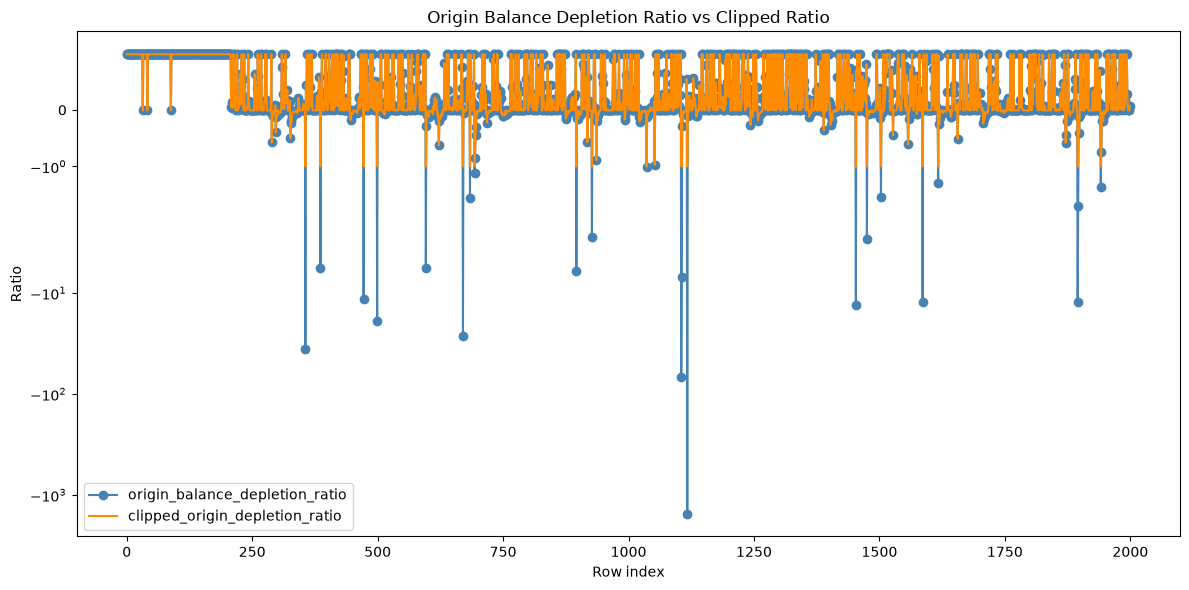

In [134]:
sample2 = model_df.sample(n=min(2000, len(model_df)), random_state=42).sort_index().reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.plot(sample2.index, sample2["origin_balance_depletion_ratio"], label="origin_balance_depletion_ratio", color="steelblue", marker="o")
plt.plot(sample2.index, sample2["clipped_origin_depletion_ratio"], label="clipped_origin_depletion_ratio", color="darkorange")

plt.yscale("symlog")

plt.title("Origin Balance Depletion Ratio vs Clipped Ratio")
plt.xlabel("Row index")
plt.ylabel("Ratio")
plt.legend()
plt.tight_layout()
plt.show()

In [135]:
model_df["origin_balance_fully_depleted"] = (
    model_df["origin_balance_depletion_ratio"] >= 0.999
).astype(int)

model_df["origin_balance_fully_depleted"].value_counts(dropna=False)

origin_balance_fully_depleted
0    8426
1    2716
Name: count, dtype: int64

```mermaid
flowchart TD
    A["Origin Behavior Feature Family"] --> B["Raw balances"]
    A --> C["Money movement"]
    A --> D["Ratios"]
    B --> B1["oldbalanceOrg"]
    B --> B2["newbalanceOrig"]
    C --> C1["origin_change"]
    C --> C2["balance_error"]
    C2 --> C3["balance_match"]
    D --> D1["amount/origin"]
    D --> D2["depletion"]
    D2 --> D3["full_depletion"]
    B1 --> F["Fraud signal"]
    B2 --> F
    C1 --> F
    C3 --> F
    D1 --> F
    D3 --> F
```

| Feature | Status |
|---|---|
| amount | <span style="color:green">Keep</span> |
| log_amount | <span style="color:green">Keep</span> |
| type | <span style="color:green">Keep</span> |
| oldbalanceOrg | <span style="color:green">Keep</span> |
| newbalanceOrig | <span style="color:green">Keep</span> |
| origin_balance_change | <span style="color:green">Keep</span> |
| origin_balance_error | <span style="color:green">Keep</span> |
| abs_origin_balance_error | <span style="color:green">Candidate</span> |
| origin_balance_match | <span style="color:green">Strong candidate</span> |
| amount_to_origin_balance_ratio | <span style="color:gold">Keep</span> |
| origin_balance_depletion_ratio | <span style="color:gold">Keep</span> |
| origin_balance_zero | <span style="color:gold">Candidate</span> |
| oldbalanceDest | <span style="color:gold">Candidate</span> |
| newbalanceDest | <span style="color:gold">Candidate</span> |
| destination_balance_change | <span style="color:green">Strong candidate</span> |
| destination_balance_error | <span style="color:gold">Candidate</span> |
| abs_destination_balance_error | <span style="color:gold">Candidate</span> |
| destination_balance_match | <span style="color:gold">Candidate</span> |
| destination_balance_zero | <span style="color:gold">Candidate</span> |
| destination_account_type | <span style="color:green">Strong candidate</span> |
| step | <span style="color:red">Exclude primary model</span> |
| nameOrig | <span style="color:red">Exclude</span> |
| nameDest | <span style="color:red">Exclude</span> |
| amount_to_destination_balance_ratio | <span style="color:red">Exclude for now</span> |
|clipped_origin_depletion_ratio	| <span style="color:green">Strong candidate</span> |
|origin_balance_fully_depleted	|  <span style="color:green">Strong candidate</span> |


## Level 3: Leakage Audit + Data Splitting

In [136]:
target_column = "isFraud"

print("Target in feature matrix:", target_column in X.columns)

Target in feature matrix: False


In [137]:
identifier_columns = [
    "nameOrig",
    "nameDest"
]

identifier_in_features = [
    col for col in identifier_columns
    if col in X.columns
]

print("Identifier columns included:", identifier_in_features)

Identifier columns included: []


In [138]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentages:")
print(
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

X shape: (11142, 20)
y shape: (11142,)

Target distribution:
isFraud
0    10000
1     1142
Name: count, dtype: int64

Target percentages:
isFraud
0    89.75
1    10.25
Name: proportion, dtype: float64


In [139]:
duplicate_count = model_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [140]:
# duplicates excluding target

duplicate_feature_rows = model_df.drop(
    columns=["isFraud"]
).duplicated().sum()

print(
    "Duplicate rows excluding target:",
    duplicate_feature_rows
)

Duplicate rows excluding target: 0


In [141]:
duplicate_feature_groups = (
    model_df
    .groupby(candidate_features)["isFraud"]
    .nunique()
)

conflicting_duplicates = (
    duplicate_feature_groups > 1
).sum()

print(
    "Feature-identical groups with conflicting labels:",
    conflicting_duplicates
)

Feature-identical groups with conflicting labels: 0


In [142]:
candidate_features = [
    # Transaction
    "amount",
    "log_amount",
    "type",

    # Origin
    "oldbalanceOrg",
    "newbalanceOrig",
    "origin_balance_change",
    "origin_balance_error",
    "abs_origin_balance_error",
    "origin_balance_match",
    "amount_to_origin_balance_ratio",
    "log_amount_to_origin_ratio", # new feature added
    "origin_balance_depletion_ratio",
    "clipped_origin_depletion_ratio", # new feature added
    "origin_balance_fully_depleted", # new feature added
    "origin_balance_zero",

    # Destination
    "oldbalanceDest",
    "newbalanceDest",
    "destination_balance_change",
    "destination_balance_error",
    "abs_destination_balance_error",
    "destination_balance_match",
    "destination_balance_zero",

    # Destination structure
    "destination_account_type"
]

X = model_df[candidate_features].copy()
y = model_df["isFraud"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11142, 23)
y shape: (11142,)


In [143]:
# stratified split
# train 70%, validation 15%, test 15%


from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30, 
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [144]:
split_summary = pd.DataFrame({
    "Dataset": [
        "Train",
        "Validation",
        "Test"
    ],
    "Samples": [
        len(y_train),
        len(y_val),
        len(y_test)
    ],
    "Fraud": [
        y_train.sum(),
        y_val.sum(),
        y_test.sum()
    ],
    "Fraud Rate (%)": [
        y_train.mean() * 100,
        y_val.mean() * 100,
        y_test.mean() * 100
    ]
})

split_summary.round(2)

,Dataset,Samples,Fraud,Fraud Rate (%)
0,Train,7799,799,10.24
1,Validation,1671,171,10.23
2,Test,1672,172,10.29


In [145]:
categorical_features = [
    "type",
    "destination_account_type"
]

numerical_features = [
    col for col in candidate_features
    if col not in categorical_features
]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 21
Categorical features: 2


## Level 4: Baseline Model (Logistic Regression)

In [146]:
# build preprocessing transformer
# num - standard scaling
# cat - one-hot encoding

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore", # ignores unknown values which wasn't seen during training
                drop="first"
            ),
            categorical_features
        )
    ]
)

In [147]:
# baseline model - logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",# to give greater importance to the minority fraud class
                random_state=42
            )
        )
    ]
)

In [148]:
# train the baseline model
logistic_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'log_amount',
                                                   'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'origin_balance_change',
                                                   'origin_balance_error',
                                                   'abs_origin_balance_error',
                                                   'origin_balance_match',
                                                   'amount_to_origin_balance_ratio',
                                                   'log_amount_to_origin_ratio',
                                                   'origin_balance_depletion_ratio',
                                                   'clipped_origi...
                                                   'newbalanceDest',
                                                   'destination_balance_change',
                                                   'destination_balance_error',
                                                   'abs_destination_balance_error',
                                                   'destination_balance_match',
                                                   'destination_balance_zero']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['type',
                                                   'destination_account_type'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [149]:
y_val_pred = logistic_pipeline.predict(X_val)

y_val_proba = logistic_pipeline.predict_proba(X_val)[:, 1]

In [150]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

validation_metrics = {
    "Accuracy": accuracy_score(y_val, y_val_pred),
    "Precision": precision_score(y_val, y_val_pred, zero_division=0),
    "Recall": recall_score(y_val, y_val_pred, zero_division=0),
    "F1 Score": f1_score(y_val, y_val_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_val, y_val_proba),
    "PR-AUC": average_precision_score(y_val, y_val_proba)
}

pd.Series(validation_metrics).round(4)

Accuracy     0.9958
Precision    0.9767
Recall       0.9825
F1 Score     0.9796
ROC-AUC      0.9987
PR-AUC       0.9939
dtype: float64

In [151]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["Legitimate", "Fraud"],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate     0.9980    0.9973    0.9977      1500
       Fraud     0.9767    0.9825    0.9796       171

    accuracy                         0.9958      1671
   macro avg     0.9874    0.9899    0.9886      1671
weighted avg     0.9958    0.9958    0.9958      1671



In [152]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_val,
    y_val_pred
)

cm

array([[1496,    4],
       [   3,  168]], dtype=int64)

In [153]:
cm_df = pd.DataFrame(
    cm,
    index=["Actual Legitimate", "Actual Fraud"],
    columns=["Predicted Legitimate", "Predicted Fraud"]
)

cm_df

,Predicted Legitimate,Predicted Fraud
Actual Legitimate,1496,4
Actual Fraud,3,168


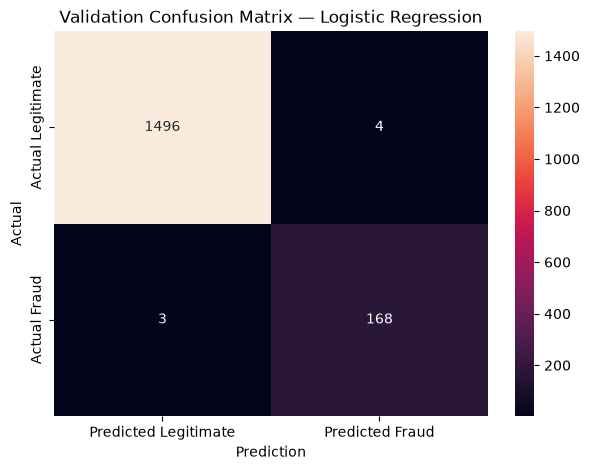

In [154]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d"
)

plt.title("Validation Confusion Matrix — Logistic Regression")
plt.xlabel("Prediction")
plt.ylabel("Actual")

plt.show()

In [155]:
probability_summary = pd.DataFrame({
    "Actual": y_val.values,
    "Fraud_Probability": y_val_proba
})

probability_summary.groupby("Actual")[
    "Fraud_Probability"
].describe().round(4)

,count,mean,std,min,25%,50%,75%,max
Actual,,,,,,,,
0,1500.0,0.0162,0.0564,0.0000,0.0002,0.0009,0.0018,0.6369
1,171.0,0.9805,0.1191,0.0297,0.9986,0.9998,1.0000,1.0000


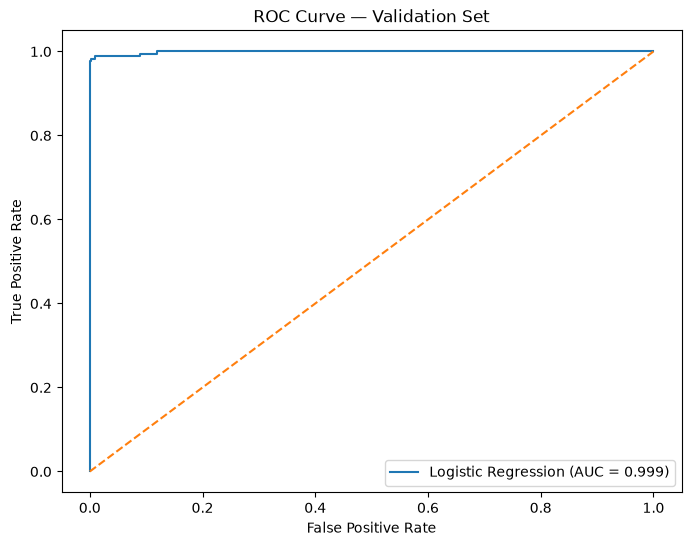

In [156]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_val,
    y_val_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {validation_metrics['ROC-AUC']:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Validation Set")
plt.legend()

plt.show()

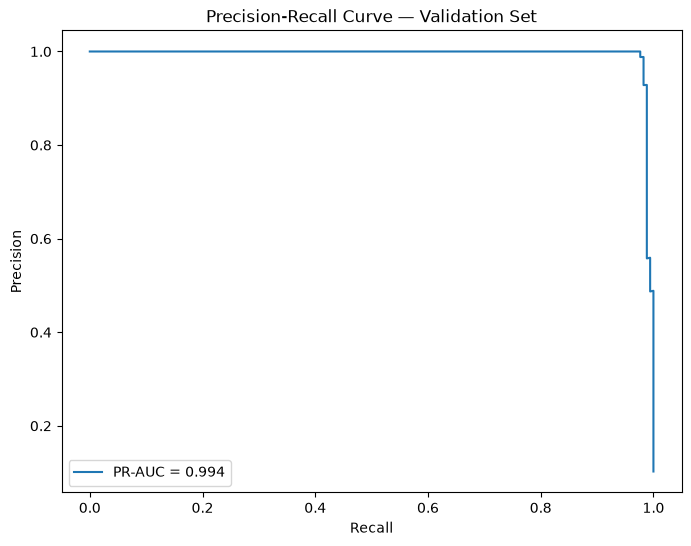

In [157]:
from sklearn.metrics import precision_recall_curve

precision, recall, pr_thresholds = precision_recall_curve(
    y_val,
    y_val_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {validation_metrics['PR-AUC']:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Validation Set")
plt.legend()

plt.show()

The PR curve shows that the model maintains very high precision across almost the entire recall range, with degradation occurring only very close to the extreme end.

In [158]:
feature_names = logistic_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = logistic_pipeline.named_steps[
    "classifier"
].coef_[0]

coefficient_analysis = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
}).sort_values(
    "abs_coefficient",
    ascending=False
)

coefficient_analysis.head(20)

,feature,coefficient,abs_coefficient
7,num__origin_balance_match,4.016903,4.016903
12,num__origin_balance_fully_depleted,3.768603,3.768603
13,num__origin_balance_zero,3.172520,3.172520
25,cat__destination_account_type_Merchant,-1.973943,1.973943
23,cat__type_PAYMENT,-1.973943,1.973943
21,cat__type_CASH_OUT,1.529347,1.529347
4,num__origin_balance_change,1.263739,1.263739
0,num__amount,1.223163,1.223163
20,num__destination_balance_zero,1.187309,1.187309
1,num__log_amount,1.045254,1.045254


A transaction whose origin balance reduction closely matches the transaction amount is highly associated with fraud in this dataset.

In [159]:
origin_signal_overlap = pd.crosstab(
    model_df["origin_balance_match"],
    model_df["origin_balance_fully_depleted"],
    margins=True
)

origin_signal_overlap

origin_balance_fully_depleted,0,1,All
origin_balance_match,,,
0,4406,1607,6013
1,4020,1109,5129
All,8426,2716,11142


In [160]:
origin_signal_analysis = (
    model_df
    .groupby("isFraud")[
        [
            "origin_balance_match",
            "origin_balance_fully_depleted",
            "origin_balance_zero"
        ]
    ]
    .mean()
    .mul(100)
    .round(2)
)

origin_signal_analysis

,origin_balance_match,origin_balance_fully_depleted,origin_balance_zero
isFraud,,,
0,40.18,16.03,24.36
1,97.29,97.46,1.75


In [161]:
# correlation among engineered num features

origin_corr = model_df[
    [
        "origin_balance_match",
        "origin_balance_fully_depleted",
        "origin_balance_zero",
        "amount_to_origin_balance_ratio",
        "log_amount_to_origin_ratio",
        "origin_balance_depletion_ratio",
        "clipped_origin_depletion_ratio",
        "origin_balance_change",
        "origin_balance_error"
    ]
].corr()

origin_corr.round(3)

,origin_balance_match,origin_balance_fully_depleted,origin_balance_zero,amount_to_origin_balance_ratio,log_amount_to_origin_ratio,origin_balance_depletion_ratio,clipped_origin_depletion_ratio,origin_balance_change,origin_balance_error
origin_balance_match,1.000,-0.059,-0.491,-0.045,-0.198,0.026,0.179,0.196,0.415
origin_balance_fully_depleted,-0.059,1.000,-0.302,0.081,0.656,0.027,0.872,0.289,0.118
origin_balance_zero,-0.491,-0.302,1.000,-0.027,-0.270,0.008,-0.348,-0.071,-0.150
amount_to_origin_balance_ratio,-0.045,0.081,-0.027,1.000,0.334,-0.126,0.063,-0.007,-0.040
log_amount_to_origin_ratio,-0.198,0.656,-0.270,0.334,1.000,-0.148,0.561,0.040,-0.033
origin_balance_depletion_ratio,0.026,0.027,0.008,-0.126,-0.148,1.000,0.086,0.017,0.048
clipped_origin_depletion_ratio,0.179,0.872,-0.348,0.063,0.561,0.086,1.000,0.290,0.265
origin_balance_change,0.196,0.289,-0.071,-0.007,0.040,0.017,0.290,1.000,0.140
origin_balance_error,0.415,0.118,-0.150,-0.040,-0.033,0.048,0.265,0.140,1.000


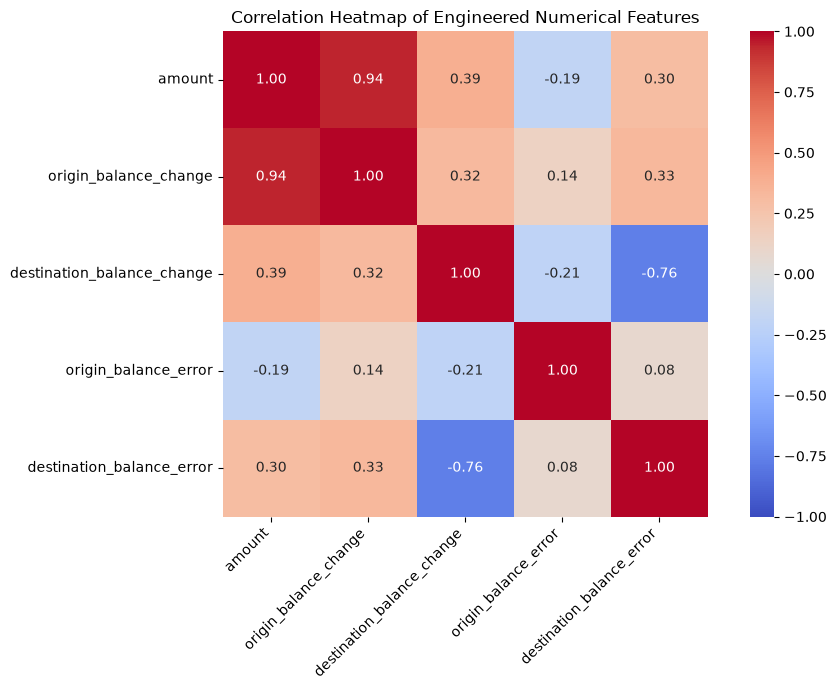

In [162]:
plt.figure(figsize=(10, 7))

correlation_matrix_val = origin_corr.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    fmt=".2f",
    square=True
)

plt.title("Correlation Heatmap of Engineered Numerical Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [163]:
feature_signal_summary = (
    model_df.groupby("isFraud")[
        [
            "origin_balance_match",
            "origin_balance_fully_depleted",
            "origin_balance_zero",
            "destination_balance_match",
            "destination_balance_zero"
        ]
    ]
    .mean()
    .mul(100)
    .round(2)
)

feature_signal_summary

,origin_balance_match,origin_balance_fully_depleted,origin_balance_zero,destination_balance_match,destination_balance_zero
isFraud,,,,,
0,40.18,16.03,24.36,6.61,56.77
1,97.29,97.46,1.75,42.03,63.75


In [164]:
# full feature correlation with target

feature_target_corr = (
    model_df[
        [
            "amount",
            "oldbalanceOrg",
            "newbalanceOrig",
            "origin_balance_change",
            "origin_balance_error",
            "origin_balance_match",
            "origin_balance_fully_depleted",
            "origin_balance_zero",
            "oldbalanceDest",
            "newbalanceDest",
            "destination_balance_change",
            "destination_balance_error",
            "destination_balance_match",
            "destination_balance_zero"
        ]
    ]
    .corrwith(model_df["isFraud"])
    .sort_values(key=abs, ascending=False)
)

feature_target_corr.round(4)

origin_balance_fully_depleted    0.5752
origin_balance_change            0.4872
amount                           0.4355
destination_balance_match        0.3544
origin_balance_match             0.3475
destination_balance_error        0.1780
origin_balance_zero             -0.1654
origin_balance_error             0.1412
newbalanceOrig                  -0.1279
destination_balance_change       0.1240
oldbalanceDest                  -0.0566
oldbalanceOrg                    0.0464
destination_balance_zero         0.0428
newbalanceDest                  -0.0029
dtype: float64

In [165]:
# ABLATION EXPERIMENT

raw_features = [
    "amount",
    "type",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "destination_account_type"
]

origin_features = [
    "origin_balance_change",
    "origin_balance_error",
    "abs_origin_balance_error",
    "origin_balance_match",
    "origin_balance_fully_depleted",
    "origin_balance_zero",
    "amount_to_origin_balance_ratio",
    "log_amount_to_origin_ratio",
    "origin_balance_depletion_ratio",
    "clipped_origin_depletion_ratio"
]

destination_features = [
    "destination_balance_change",
    "destination_balance_error",
    "abs_destination_balance_error",
    "destination_balance_match",
    "destination_balance_zero"
]

full_features = raw_features + origin_features + destination_features + ["log_amount"]

print("Raw:", len(raw_features))
print("Origin:", len(origin_features))
print("Destination:", len(destination_features))
print("Full:", len(full_features))

Raw: 7
Origin: 10
Destination: 5
Full: 23


In [166]:
def prepare_feature_split(features):
    X_train_subset = X_train[features].copy()
    X_val_subset = X_val[features].copy()

    categorical = [
        col for col in features
        if X_train_subset[col].dtype == "object"
    ]

    numerical = [
        col for col in features
        if col not in categorical
    ]

    return (
        X_train_subset,
        X_val_subset,
        numerical,
        categorical
    )

In [167]:
from sklearn.base import clone

feature_sets = {
    "Raw": raw_features,
    "Raw + Origin": raw_features + origin_features,
    "Raw + Destination": raw_features + destination_features,
    "Full": full_features
}

ablation_results = []

for model_name, features in feature_sets.items():

    # Remove duplicate feature names safely
    features = list(dict.fromkeys(features))

    Xtr, Xv, num_cols, cat_cols = prepare_feature_split(features)

    preprocessor_ablation = ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                num_cols
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first"
                ),
                cat_cols
            )
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor_ablation),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=42
                )
            )
        ]
    )

    model.fit(Xtr, y_train)

    pred = model.predict(Xv)
    proba = model.predict_proba(Xv)[:, 1]

    ablation_results.append({
        "Model": model_name,
        "Features": len(features),
        "Precision": precision_score(
            y_val, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val, pred, zero_division=0
        ),
        "F1": f1_score(
            y_val, pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_val, proba
        ),
        "PR-AUC": average_precision_score(
            y_val, proba
        )
    })

ablation_results_df = pd.DataFrame(ablation_results)

ablation_results_df.round(4)

,Model,Features,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Raw,7,0.4683,0.9942,0.6367,0.9898,0.9358
1,Raw + Origin,17,0.9882,0.9825,0.9853,0.9981,0.9925
2,Raw + Destination,12,0.6833,0.9591,0.7981,0.9889,0.8981
3,Full,23,0.9767,0.9825,0.9796,0.9987,0.9939


Origin-side transaction behavior contains substantially more predictive information than destination-side behavior in this dataset.

Adding destination features doesn't necessarily improve the default 0.50 classification decision, but it slightly improves the model's overall probability ranking.

Finally - Raw + Origin or Full

Feature engineering had a much larger impact than simply selecting a more complicated algorithm.

In [168]:
# Targeted Feature Ablation

origin_core_features = [
    "origin_balance_change",
    "origin_balance_error",
    "abs_origin_balance_error",
    "origin_balance_match",
    "origin_balance_fully_depleted"
]

origin_optional_features = [
    "origin_balance_zero",
    "amount_to_origin_balance_ratio",
    "log_amount_to_origin_ratio",
    "origin_balance_depletion_ratio",
    "clipped_origin_depletion_ratio"
]

raw_features = [
    "amount",
    "type",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "destination_account_type"
]

targeted_feature_sets = {
    "Raw + Origin Core":
        raw_features + origin_core_features,

    "Core + Zero":
        raw_features + origin_core_features + [
            "origin_balance_zero"
        ],

    "Core + Ratios":
        raw_features + origin_core_features + [
            "amount_to_origin_balance_ratio",
            "log_amount_to_origin_ratio",
            "origin_balance_depletion_ratio",
            "clipped_origin_depletion_ratio"
        ],

    "Full Origin": raw_features + origin_core_features + origin_optional_features
}

In [169]:
targeted_results = []

for model_name, features in targeted_feature_sets.items():

    features = list(dict.fromkeys(features))

    Xtr = X_train[features].copy()
    Xv = X_val[features].copy()

    categorical = [
        col for col in features
        if Xtr[col].dtype == "object"
    ]

    numerical = [
        col for col in features
        if col not in categorical
    ]

    prep = ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                numerical
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first"
                ),
                categorical
            )
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", prep),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=42
                )
            )
        ]
    )

    model.fit(Xtr, y_train)

    pred = model.predict(Xv)
    proba = model.predict_proba(Xv)[:, 1]

    targeted_results.append({
        "Model": model_name,
        "Features": len(features),
        "Precision": precision_score(
            y_val, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val, pred, zero_division=0
        ),
        "F1": f1_score(
            y_val, pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_val, proba
        ),
        "PR-AUC": average_precision_score(
            y_val, proba
        )
    })

targeted_results_df = pd.DataFrame(targeted_results)

targeted_results_df.round(4)

,Model,Features,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Raw + Origin Core,12,0.9027,0.9766,0.9382,0.9977,0.9902
1,Core + Zero,13,0.9940,0.9766,0.9853,0.9982,0.9928
2,Core + Ratios,16,0.9333,0.9825,0.9573,0.9975,0.9909
3,Full Origin,17,0.9882,0.9825,0.9853,0.9981,0.9925


Logistic Regression candidates: (Core + Zero)

|Raw|Origin Core|Additional|
|---|---|---|
|amount|origin_balance_change|origin_balance_zero|
|type|origin_balance_error|
|oldbalanceOrg|abs_origin_balance_error|
|newbalanceOrig|origin_balance_match|
|oldbalanceDest|origin_balance_fully_depleted|
|newbalanceDest|
|destination_account_type|

Total:
13 features

## Level 5: Random Forest

In [170]:
selected_features = [
    # Raw transaction
    "amount",
    "type",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "destination_account_type",

    # Origin behavior
    "origin_balance_change",
    "origin_balance_error",
    "abs_origin_balance_error",
    "origin_balance_match",
    "origin_balance_fully_depleted",
    "origin_balance_zero"
]

print("Selected features:", len(selected_features))

Selected features: 13


In [171]:
X_train_rf = X_train[selected_features].copy()
X_val_rf = X_val[selected_features].copy()

categorical_rf = [
    col for col in selected_features
    if X_train_rf[col].dtype == "object"
]

numerical_rf = [
    col for col in selected_features
    if col not in categorical_rf
]

print("Numerical:", len(numerical_rf))
print("Categorical:", len(categorical_rf))

Numerical: 11
Categorical: 2


In [172]:
# random forest pipeline

from sklearn.ensemble import RandomForestClassifier

rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_rf
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_rf
        )
    ]
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=400,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
                min_samples_leaf=2
            )
        )
    ]
)

In [173]:
rf_pipeline.fit(X_train_rf,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'origin_balance_change',
                                                   'origin_balance_error',
                                                   'abs_origin_balance_error',
                                                   'origin_balance_match',
                                                   'origin_balance_fully_depleted',
                                                   'origin_balance_zero']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['type',
                                                   'destination_account_type'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=2, n_estimators=400,
                                        n_jobs=-1, random_state=42))])

In [174]:
# evaluation 

rf_val_pred = rf_pipeline.predict(X_val_rf)

rf_val_proba = rf_pipeline.predict_proba(
    X_val_rf
)[:, 1]

rf_metrics = {
    "Accuracy": accuracy_score(
        y_val,
        rf_val_pred
    ),
    "Precision": precision_score(
        y_val,
        rf_val_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val,
        rf_val_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_val,
        rf_val_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_val,
        rf_val_proba
    ),
    "PR-AUC": average_precision_score(
        y_val,
        rf_val_proba
    )
}

pd.Series(rf_metrics).round(4)

Accuracy     0.9982
Precision    1.0000
Recall       0.9825
F1           0.9912
ROC-AUC      0.9985
PR-AUC       0.9946
dtype: float64

In [175]:
len(y_val)

1671

In [176]:
y_val.value_counts()

isFraud
0    1500
1     171
Name: count, dtype: int64

Precision = 100%, FP = 0
Recall = 98.25%, FN = 3 (0.9825 * 171 = 168)

| Metric | Logistic Regression (%) | Random Forest (%) | Point change |
|---|---:|---:|---:|
| Accuracy | 99.58% | 99.82% | +0.24 pp |
| Precision | 97.67% | 100.00% | +2.33 pp |
| Recall | 98.25% | 98.25% | +0.00 pp |
| F1 Score | 97.96% | 99.12% | +1.16 pp |
| ROC-AUC | 99.87% | 99.85% | -0.03 pp |
| PR-AUC | 99.39% | 99.46% | +0.07 pp |


The model that ranks probabilities best isn't necessarily the model that gives the best classification decisions at threshold 0.50.

In [177]:
# rf feature importance

rf_feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

rf_importances = rf_pipeline.named_steps[
    "classifier"
].feature_importances_

rf_feature_importance = (
    pd.DataFrame({
        "feature": rf_feature_names,
        "importance": rf_importances
    })
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

rf_feature_importance.head(20)

,feature,importance
0,num__origin_balance_change,0.220550
1,num__origin_balance_fully_depleted,0.211945
2,num__abs_origin_balance_error,0.111973
3,num__newbalanceOrig,0.097219
4,num__origin_balance_error,0.094975
5,num__origin_balance_match,0.075713
6,cat__type_PAYMENT,0.047131
7,cat__destination_account_type_Merchant,0.043790
8,num__amount,0.031035
9,num__oldbalanceOrg,0.018104


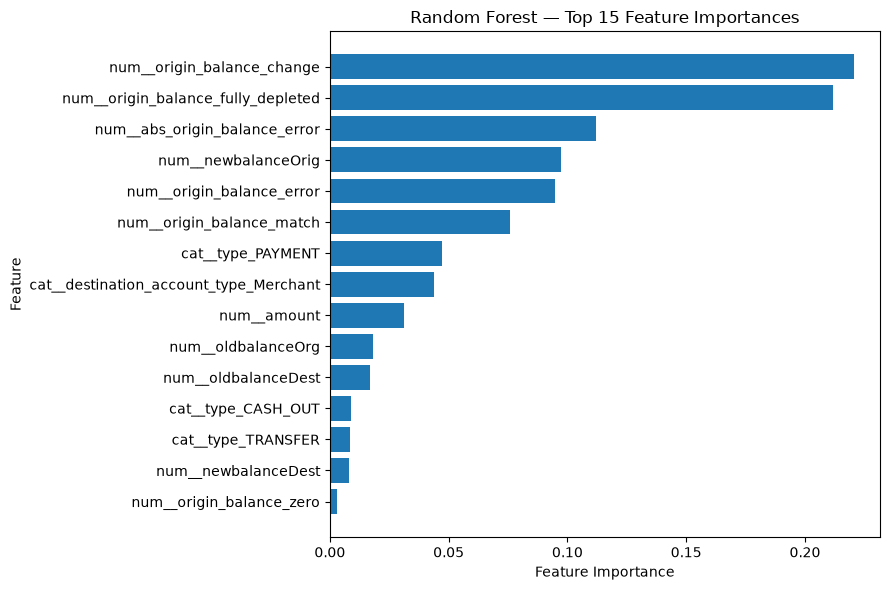

In [178]:
top_rf_features = rf_feature_importance.head(15).sort_values(
    "importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_rf_features["feature"],
    top_rf_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest — Top 15 Feature Importances")

plt.tight_layout()
plt.show()

In [179]:
# permutation importance
from sklearn.inspection import permutation_importance

rf_permutation = permutation_importance(
    rf_pipeline,
    X_val_rf,
    y_val,
    scoring="average_precision",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [180]:
rf_perm_names = X_val_rf.columns

rf_perm_importance = (
    pd.DataFrame({
        "feature": rf_perm_names,
        "importance_mean": rf_permutation.importances_mean,
        "importance_std": rf_permutation.importances_std
    })
    .sort_values(
        "importance_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

rf_perm_importance.head(15)

,feature,importance_mean,importance_std
0,origin_balance_fully_depleted,0.060777,0.012264
1,newbalanceOrig,0.006935,0.000136
2,origin_balance_match,0.006100,0.001349
3,type,0.005779,0.000290
4,origin_balance_error,0.005423,0.001075
5,abs_origin_balance_error,0.005195,0.001098
6,origin_balance_change,0.004302,0.001028
7,amount,0.004298,0.000474
8,oldbalanceDest,0.003829,0.002051
9,oldbalanceOrg,0.002447,0.001398


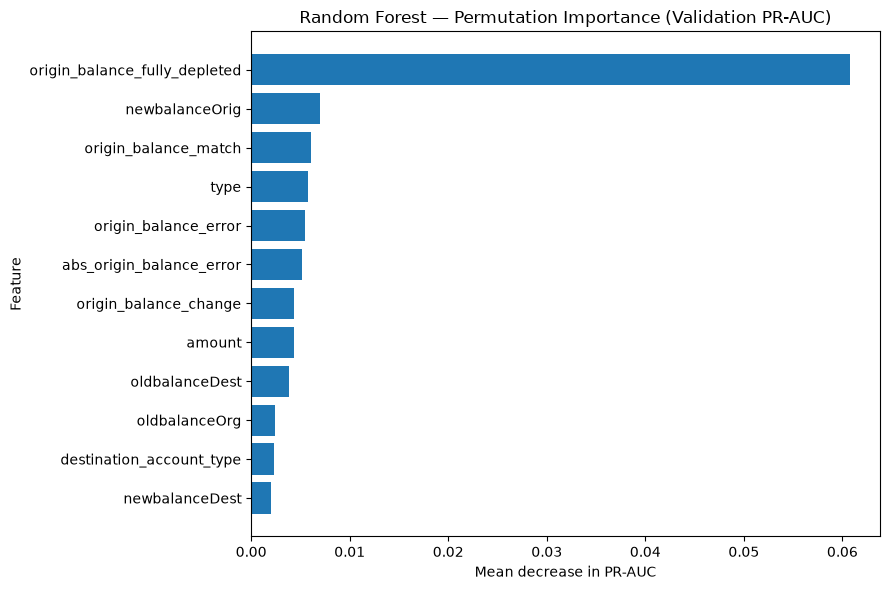

In [181]:
top_perm = (
    rf_perm_importance
    .head(12)
    .sort_values("importance_mean")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_perm["feature"],
    top_perm["importance_mean"]
)

plt.xlabel("Mean decrease in PR-AUC")
plt.ylabel("Feature")
plt.title(
    "Random Forest — Permutation Importance "
    "(Validation PR-AUC)"
)

plt.tight_layout()
plt.show()

"Origin-account full depletion emerged as the strongest predictive signal across multiple analyses, including target association, Logistic Regression coefficients, Random Forest impurity importance, and permutation importance."

## Level 6: Gradient Boosting (XGBoost Baseline)

In [182]:
import xgboost

print("XGBoost version:", xgboost.__version__)

ModuleNotFoundError: No module named 'xgboost'

In [183]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe

Python version:
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [184]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "xgboost"
])

0

In [185]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [186]:
xgb_features = selected_features.copy()

X_train_xgb = X_train[xgb_features].copy()
X_val_xgb = X_val[xgb_features].copy()

categorical_xgb = [
    col for col in xgb_features
    if X_train_xgb[col].dtype == "object"
]

numerical_xgb = [
    col for col in xgb_features
    if col not in categorical_xgb
]

print("Total features:", len(xgb_features))
print("Numerical features:", len(numerical_xgb))
print("Categorical features:", len(categorical_xgb))

Total features: 13
Numerical features: 11
Categorical features: 2


In [187]:
# preprocess

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

xgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_xgb
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_xgb
        )
    ]
)

In [189]:
X_train_xgb_encoded = xgb_preprocessor.fit_transform(X_train_xgb)

X_val_xgb_encoded = xgb_preprocessor.transform(X_val_xgb)

print("Encoded train shape:", X_train_xgb_encoded.shape)
print("Encoded validation shape:", X_val_xgb_encoded.shape)

# cat columns may expands by one-hot encoding

Encoded train shape: (7799, 16)
Encoded validation shape: (1671, 16)


In [190]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier( # baseline model not complex
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

In [191]:
xgb_model.fit(
    X_train_xgb_encoded,
    y_train,
    eval_set=[
        (X_val_xgb_encoded, y_val)
    ],
    verbose=False
)

print("XGBoost training complete.")

XGBoost training complete.


In [192]:
xgb_val_pred = xgb_model.predict(X_val_xgb_encoded)

xgb_val_proba = xgb_model.predict_proba(X_val_xgb_encoded)[:, 1]

In [193]:
xgb_metrics = {
    "Accuracy": accuracy_score(
        y_val,
        xgb_val_pred
    ),
    "Precision": precision_score(
        y_val,
        xgb_val_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val,
        xgb_val_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_val,
        xgb_val_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_val,
        xgb_val_proba
    ),
    "PR-AUC": average_precision_score(
        y_val,
        xgb_val_proba
    )
}

pd.Series(xgb_metrics).round(4)

Accuracy     0.9982
Precision    1.0000
Recall       0.9825
F1           0.9912
ROC-AUC      0.9973
PR-AUC       0.9922
dtype: float64

With the current feature set and baseline hyperparameters, Random Forest provides the strongest validation performance among the three tested models.

Now we can tune the two strongest nonlinear candidates: Random Forest and XGBoost

We don't need to spend significant tuning effort on Logistic Regression anymore.

#### Random Forest feature reduction

In [195]:
# origin_balance_zero -> 0.000286 (perm impo almost negligible)
# remove origin_balance_zero

rf_reduced_features = [
    "amount",
    "type",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "destination_account_type",

    "origin_balance_change",
    "origin_balance_error",
    "abs_origin_balance_error",
    "origin_balance_match",
    "origin_balance_fully_depleted"
]

In [196]:
X_train_rf_reduced = X_train[rf_reduced_features].copy()
X_val_rf_reduced = X_val[rf_reduced_features].copy()

categorical_rf_reduced = [
    col for col in rf_reduced_features
    if X_train_rf_reduced[col].dtype == "object"
]

numerical_rf_reduced = [
    col for col in rf_reduced_features
    if col not in categorical_rf_reduced
]

rf_reduced_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_rf_reduced
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_rf_reduced
        )
    ]
)

In [197]:
rf_reduced_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_reduced_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=400,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
                min_samples_leaf=2
            )
        )
    ]
)

rf_reduced_pipeline.fit(
    X_train_rf_reduced,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'origin_balance_change',
                                                   'origin_balance_error',
                                                   'abs_origin_balance_error',
                                                   'origin_balance_match',
                                                   'origin_balance_fully_depleted']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['type',
                                                   'destination_account_type'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=2, n_estimators=400,
                                        n_jobs=-1, random_state=42))])

In [198]:
rf_reduced_pred = rf_reduced_pipeline.predict(
    X_val_rf_reduced
)

rf_reduced_proba = rf_reduced_pipeline.predict_proba(
    X_val_rf_reduced
)[:, 1]

rf_reduced_metrics = {
    "Accuracy": accuracy_score(
        y_val,
        rf_reduced_pred
    ),
    "Precision": precision_score(
        y_val,
        rf_reduced_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val,
        rf_reduced_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_val,
        rf_reduced_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_val,
        rf_reduced_proba
    ),
    "PR-AUC": average_precision_score(
        y_val,
        rf_reduced_proba
    )
}

pd.Series(rf_reduced_metrics).round(4)

Accuracy     0.9982
Precision    1.0000
Recall       0.9825
F1           0.9912
ROC-AUC      0.9982
PR-AUC       0.9943
dtype: float64

The nonlinear Random Forest is able to capture information associated with zero origin balance through other features, whereas Logistic Regression benefits from explicitly including the feature.

| Model | Features | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|---:|
| Logistic Regression | 13 | 97.67% | 98.25% | 97.96% | 99.87% | 99.39% |
| Random Forest Reduced | 12 | 100.00% | 98.25% | 99.12% | 99.82% | 99.43% |
| XGBoost | 13 | 100.00% | 98.25% | 99.12% | 99.73% | 99.22% |

## Level 7: RF Hyperparameter Tuning

In [200]:
# stratified cross-validation on the training data

rf_tuning_features = [
    "amount",
    "type",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "destination_account_type",
    "origin_balance_change",
    "origin_balance_error",
    "abs_origin_balance_error",
    "origin_balance_match",
    "origin_balance_fully_depleted"
]

print("RF tuning features:", len(rf_tuning_features))

RF tuning features: 12


In [201]:
X_train_rf_tune = X_train[rf_tuning_features].copy()

categorical_rf_tune = [
    col for col in rf_tuning_features
    if X_train_rf_tune[col].dtype == "object"
]

numerical_rf_tune = [
    col for col in rf_tuning_features
    if col not in categorical_rf_tune
]

In [202]:
rf_tune_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_rf_tune
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_rf_tune
        )
    ]
)

rf_tune_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_tune_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [203]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

rf_param_distributions = {
    "classifier__n_estimators": [
        300, 500, 700
    ],
    "classifier__max_depth": [
        None, 8, 12, 16, 20
    ],
    "classifier__min_samples_split": [
        2, 5, 10
    ],
    "classifier__min_samples_leaf": [
        1, 2, 4
    ],
    "classifier__max_features": [
        "sqrt",
        "log2",
        0.7
    ]
}

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_search = RandomizedSearchCV(
    estimator=rf_tune_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=20,
    scoring="average_precision",
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)